## Perceptrón Multicapa (MLP) entrenado para dataset de detección visual de personajes de los Simpsons

<p align="center"><img src="../images/logoLosSimpsons.png" alt="Logo de Los Simpsons" width="600"></p>

#### Integrantes:

    - VINCENT FARENDEN CERON
    - RODRIGO IGNACIO MARTINEZ BECKER
    - DIEGO IGNACIO PENA Y LILLO LUHRS

#### Asignatura:

    - MACHINE LEARNING_001D

#### Profesor:

    - FRANCISCO JAVIER JEREZ SALAZAR

#### Fecha:

    - 13-09-2026

## Definición del Dataset

Nuestro conjunto de datos se presenta como dos carpetas de entreno y pruebas en donde ambas presentan la misma estructura de imagenes, una carpeta por personaje definido con varias imagenes de estos desde varios puntos de vista. Nosotros escogimos este dataset debido a la gran popularidad de los personajes y porque tienen una identidad gráfica extremadamente reconocible: piel amarilla, siluetas simples, colores fuertes y personajes fáciles de distinguir incluso con pocos detalles. Su diseño es consistente y memorable, lo que hace que la serie destaque inmediatamente frente a otras animaciones.

![Homero](../images/homero.png) ![Lisa](../images/lisa.png)

## Definición del problema de clasificación

El problema que abordamos es de **clasificación de imágenes multiclase de etiqueta única**: dada una imagen RGB que contiene a un personaje de Los Simpsons, el modelo debe asignarle **exactamente una** de las 25 clases posibles (una por personaje). No es detección de objetos ni clasificación multi-etiqueta: no se predicen cajas delimitadoras ni varios personajes por imagen.

**Entrada y salida**

- **Entrada (X):** imagen RGB de tamaño variable (aprox. entre 256x257 y 720x464 px). Para el Perceptrón Multicapa se redimensionará a un tamaño fijo, se normalizarán los píxeles al rango [0, 1] y se aplanará la imagen en un vector, ya que el MLP no acepta estructura espacial 2D.
- **Salida (y):** vector de 25 probabilidades (activación *softmax*); la clase predicha es la de mayor probabilidad.
- **Función de pérdida:** entropía cruzada categórica (*categorical crossentropy*).

**Conjuntos de datos**

| Conjunto | Imágenes | Clases |
|---|---|---|
| train | 16.137 | 25 |
| test | 3.937 | 25 |

**Desbalance de clases**

Las clases están fuertemente desbalanceadas: en entrenamiento van desde 1.796 imágenes de `homer_simpson` hasta 82 de `selma_bouvier` (razón aproximada de 22:1). Esto implica que la *accuracy* por sí sola es una métrica engañosa, y que el modelo tenderá a favorecer a los personajes mayoritarios.

**Baselines de referencia**

- Clasificador aleatorio: 1/25 = **4,0 %** de accuracy.
- Clasificador de clase mayoritaria (predecir siempre `homer_simpson`): 450/3.937 = **11,4 %** en test.

Cualquier modelo útil debe superar claramente estos valores.

**Métricas de evaluación**

Además de la *accuracy* global se reportarán **precision, recall y F1-score por clase**, el **F1 macro** (que pondera igual a todas las clases, mostrando el efecto del desbalance) y la **matriz de confusión**, útil para detectar confusiones sistemáticas entre personajes visualmente parecidos (por ejemplo, Bart y Milhouse, o Lisa y Maggie).

**Dificultades esperadas**

Como se puede ver en las imágenes del apartado anterior, tanto Homero como Lisa aparecen en múltiples poses, con distintos encuadres, escalas y fondos, y con variaciones de color debidas a las diferentes temporadas. A esto se suman personajes parcialmente ocluidos o acompañados por otros en la misma escena, y la pérdida de información espacial al aplanar la imagen para el MLP, lo que limita el rendimiento alcanzable frente a arquitecturas convolucionales.

**Supuestos**

Se asume que cada imagen contiene un único personaje relevante (el que da nombre a su carpeta) y que la partición train/test provista por el dataset es válida, es decir, que no existen imágenes duplicadas entre ambos conjuntos.

## Pre-Procesamiento de los datos

En esta sección se prepara el dataset para que pueda ser consumido por una red densa: se cargan las rutas e imágenes, se llevan todas a un tamaño fijo, se normalizan los valores de píxel, se aplanan a vectores y se codifican las etiquetas.

### Definición del conjunto de datos a utilizar

In [1]:
from pathlib import Path

DATASET_BASE = Path("C:/Users/Diego/Desktop/Trabajos/LosSimpsonsDataset")
CONJUNTOS_VALIDOS = ("train", "test")

# Cambiar a ( 'train' / 'test' ) según lel conjunto que quieras correr
conjunto = "train"

conjunto = conjunto.strip().lower()
if conjunto not in CONJUNTOS_VALIDOS:
    raise ValueError(
        f'Conjunto inválido: "{conjunto}". Usa uno de: {CONJUNTOS_VALIDOS}'
    )

direccion_dataset = DATASET_BASE / conjunto

if not direccion_dataset.is_dir():
    raise FileNotFoundError(f"No existe el directorio: {direccion_dataset}")

print(f'Se está utilizando el conjunto "{conjunto}" en: {direccion_dataset}')

Se está utilizando el conjunto "train" en: C:\Users\Diego\Desktop\Trabajos\LosSimpsonsDataset\train


### Carga de imágenes y etiquetas

In [2]:
import pandas as pd

EXTENSIONES_VALIDAS = (".jpg", ".jpeg", ".png", ".bmp")


def construir_indice(directorio):
    """Recorre un directorio con una subcarpeta por clase y devuelve un
    DataFrame con la ruta de cada imagen y el personaje al que pertenece."""
    registros = []

    for carpeta_clase in sorted(directorio.iterdir()):
        if not carpeta_clase.is_dir():
            continue

        for ruta in sorted(carpeta_clase.iterdir()):
            if ruta.suffix.lower() in EXTENSIONES_VALIDAS:
                registros.append({"ruta": ruta, "personaje": carpeta_clase.name})

    if not registros:
        raise FileNotFoundError(f"No se encontraron imagenes en: {directorio}")

    return pd.DataFrame(registros)


# Indice del conjunto seleccionado en el paso anterior
datos = construir_indice(direccion_dataset)

# Lista ordenada de clases y su mapeo a indices enteros
clases = sorted(datos["personaje"].unique())
clase_a_indice = {clase: indice for indice, clase in enumerate(clases)}
indice_a_clase = {indice: clase for clase, indice in clase_a_indice.items()}

# Etiqueta numerica de cada imagen
datos["etiqueta"] = datos["personaje"].map(clase_a_indice)

# Resumen de imagenes por clase como DataFrame
resumen = (
    datos["personaje"]
    .value_counts()
    .rename_axis("personaje")
    .reset_index(name="imagenes")
)
resumen["etiqueta"] = resumen["personaje"].map(clase_a_indice)
resumen["porcentaje"] = (resumen["imagenes"] / len(datos) * 100).round(2)
resumen = resumen[["etiqueta", "personaje", "imagenes", "porcentaje"]]

print(f'Conjunto "{conjunto}": {len(datos)} imagenes en {len(clases)} clases')

display(resumen)


Conjunto "train": 16137 imagenes en 25 clases


,etiqueta,personaje,imagenes,porcentaje
0,9,homer_simpson,1796,11.13
1,19,ned_flanders,1163,7.21
2,18,moe_szyslak,1161,7.19
3,13,lisa_simpson,1083,6.71
4,3,bart_simpson,1073,6.65
5,15,marge_simpson,1032,6.40
6,11,krusty_the_clown,964,5.97
7,21,principal_skinner,955,5.92
8,4,charles_montgomery_burns,954,5.91
9,17,milhouse_van_houten,863,5.35


### Redimensionado a un tamaño fijo



In [3]:
from PIL import Image
import numpy as np

# Dimensiones originales de cada imagen del conjunto (sin cargar los pixeles)
dimensiones = []
for ruta in datos["ruta"]:
    with Image.open(ruta) as img:
        dimensiones.append(img.size)  # (ancho, alto)

datos["ancho"] = [ancho for ancho, _ in dimensiones]
datos["alto"] = [alto for _, alto in dimensiones]

resumen_dimensiones = datos[["ancho", "alto"]].describe().T
resumen_dimensiones["mediana"] = datos[["ancho", "alto"]].median()
resumen_dimensiones = resumen_dimensiones[
    ["count", "min", "25%", "mediana", "75%", "max", "mean", "std"]
].round(1)

display(resumen_dimensiones)


,count,min,25%,mediana,75%,max,mean,std
ancho,16137.0,256.0,288.0,320.0,576.0,1912.0,408.5,149.0
alto,16137.0,256.0,379.0,432.0,480.0,1072.0,416.4,63.1


**Elección y justificación del tamaño objetivo**

Las imágenes del conjunto tienen dimensiones variables, mientras que una red densa exige un vector de
entrada de longitud fija. Por lo tanto, el primer paso del pre-procesamiento consiste en llevar todas
las imágenes a una misma resolución.

La elección de esa resolución no es arbitraria, ya que condiciona directamente el tamaño del modelo.
Al aplanar la imagen, la capa de entrada queda formada por `alto x ancho x 3` valores (tres canales
RGB por píxel) y cada uno de ellos se conecta con todas las neuronas de la primera capa oculta. En
consecuencia, el número de parámetros de esa capa crece de forma cuadrática respecto del lado de la
imagen:

| Resolución | Dimensión del vector de entrada | Parámetros de la primera capa densa (512 neuronas) |
|---|---|---|
| 32 x 32 | 3.072 | ≈ 1,6 millones |
| **64 x 64** | **12.288** | **≈ 6,3 millones** |
| 128 x 128 | 49.152 | ≈ 25,2 millones |

Se adopta una resolución de **64 x 64 píxeles**, por tres razones:

1. **Suficiencia informativa.** A esa escala se conservan los rasgos que permiten discriminar entre
   personajes —silueta, color de piel, peinado y vestimenta—, que en Los Simpsons son elementos de
   diseño muy marcados y de baja frecuencia espacial, poco sensibles a la pérdida de detalle fino.
2. **Costo computacional acotado.** Duplicar el lado a 128 x 128 cuadruplica la dimensión de entrada
   y, con ella, los parámetros entrenables. Esto aumenta el tiempo de entrenamiento y el riesgo de
   sobreajuste, sin un beneficio equivalente: al aplanar la imagen el MLP pierde la estructura
   espacial, por lo que no puede explotar el detalle adicional como sí lo haría una red convolucional.
3. **Pérdida de información en resoluciones menores.** Con 32 x 32 el modelo sería más económico,
   pero la degradación compromete la distinción entre personajes visualmente similares.

En síntesis, 64 x 64 representa un compromiso razonable entre el detalle conservado y la complejidad
del modelo. Este valor se fija como referencia para el modelo base y podrá revisarse en la etapa de
experimentación.


In [4]:
ALTO_OBJETIVO, ANCHO_OBJETIVO = 64, 64
TAMANO_OBJETIVO = (ANCHO_OBJETIVO, ALTO_OBJETIVO)  # PIL usa (ancho, alto)


def cargar_y_redimensionar(ruta, tamano=TAMANO_OBJETIVO):
    """Abre una imagen, la convierte a RGB y la redimensiona al tamano fijo."""
    with Image.open(ruta) as img:
        img = img.convert("RGB").resize(tamano, Image.Resampling.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


# Matriz de imagenes redimensionadas: (n_imagenes, alto, ancho, 3)
imagenes = np.stack([cargar_y_redimensionar(ruta) for ruta in datos["ruta"]])
etiquetas = datos["etiqueta"].to_numpy()

print(f"imagenes: {imagenes.shape}  dtype={imagenes.dtype}")
print(f"etiquetas: {etiquetas.shape}")


imagenes: (16137, 64, 64, 3)  dtype=uint8
etiquetas: (16137,)


**Comprobación del redimensionado**

In [5]:
comprobaciones = pd.DataFrame(
    [
        ("Numero de imagenes", imagenes.shape[0], len(datos), imagenes.shape[0] == len(datos)),
        ("Alto", imagenes.shape[1], ALTO_OBJETIVO, imagenes.shape[1] == ALTO_OBJETIVO),
        ("Ancho", imagenes.shape[2], ANCHO_OBJETIVO, imagenes.shape[2] == ANCHO_OBJETIVO),
        ("Canales", imagenes.shape[3], 3, imagenes.shape[3] == 3),
        ("Tipo de dato", str(imagenes.dtype), "uint8", imagenes.dtype == np.uint8),
        ("Valor minimo", int(imagenes.min()), ">= 0", imagenes.min() >= 0),
        ("Valor maximo", int(imagenes.max()), "<= 255", imagenes.max() <= 255),
        ("Etiquetas alineadas", len(etiquetas), imagenes.shape[0], len(etiquetas) == imagenes.shape[0]),
    ],
    columns=["comprobacion", "obtenido", "esperado", "ok"],
)

memoria_mb = imagenes.nbytes / 1024**2
print(f"Memoria ocupada por la matriz de imagenes: {memoria_mb:.1f} MB")
print(f"Neuronas en la capa de entrada tras aplanar: {ALTO_OBJETIVO * ANCHO_OBJETIVO * 3}")

display(comprobaciones)


Memoria ocupada por la matriz de imagenes: 189.1 MB
Neuronas en la capa de entrada tras aplanar: 12288


,comprobacion,obtenido,esperado,ok
0,Numero de imagenes,16137,16137,True
1,Alto,64,64,True
2,Ancho,64,64,True
3,Canales,3,3,True
4,Tipo de dato,uint8,uint8,True
5,Valor minimo,0,>= 0,True
6,Valor maximo,255,<= 255,True
7,Etiquetas alineadas,16137,16137,True


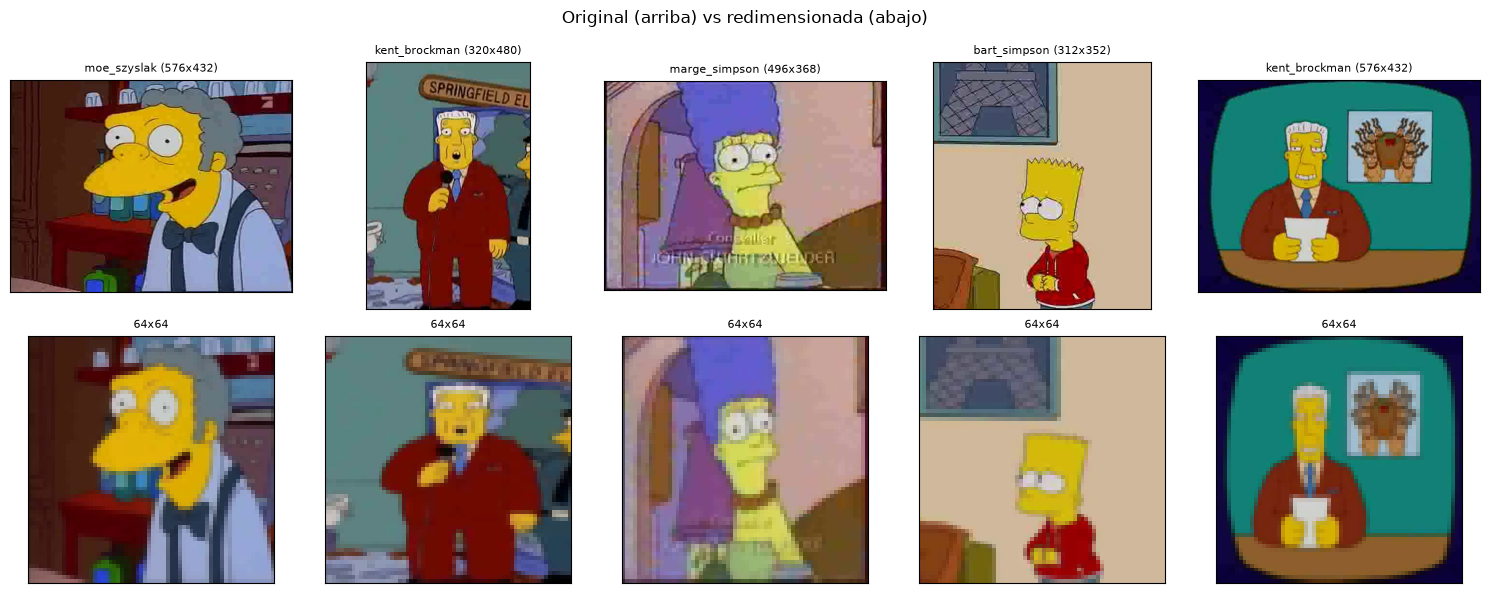

In [6]:
import matplotlib.pyplot as plt

# Comparacion visual original vs redimensionada para una muestra aleatoria
generador = np.random.default_rng(42)
muestra = generador.choice(len(datos), size=5, replace=False)

figura, ejes = plt.subplots(2, len(muestra), figsize=(3 * len(muestra), 6))
for columna, indice in enumerate(muestra):
    fila = datos.iloc[indice]
    with Image.open(fila["ruta"]) as img:
        original = img.convert("RGB")

    titulo = "{} ({}x{})".format(fila["personaje"], original.size[0], original.size[1])
    ejes[0, columna].imshow(original)
    ejes[0, columna].set_title(titulo, fontsize=8)
    ejes[1, columna].imshow(imagenes[indice])
    ejes[1, columna].set_title("{}x{}".format(ANCHO_OBJETIVO, ALTO_OBJETIVO), fontsize=8)

    for eje in (ejes[0, columna], ejes[1, columna]):
        eje.set_xticks([])
        eje.set_yticks([])

figura.suptitle("Original (arriba) vs redimensionada (abajo)")
figura.tight_layout()
plt.show()


### Normalización de los píxeles



**Por que normalizar**

Los pixeles se almacenan como enteros `uint8` en el rango [0, 255]. Si se alimentan directamente a la
red, las combinaciones lineales de la primera capa producen valores de magnitud muy grande: las
activaciones sigmoide o tanh se saturan (gradiente practicamente nulo) y, con ReLU, los gradientes
resultan muy dispares entre si, lo que obliga a usar tasas de aprendizaje muy pequenas y hace
inestable el descenso del gradiente.

Al dividir por 255 todas las caracteristicas de entrada quedan en la misma escala acotada [0, 1]. Esto
mantiene las preactivaciones en un rango razonable, hace comparables las magnitudes de los gradientes
entre pixeles y permite que la inicializacion estandar de los pesos de Keras funcione como se espera.

Se convierte ademas a `float32`, que es el tipo con el que opera Keras: es la mitad de memoria que
`float64` y evita conversiones implicitas en cada batch.


In [7]:
# Escalado de [0, 255] a [0, 1] en float32 (tipo con el que opera Keras)
VALOR_MAXIMO_PIXEL = 255.0

imagenes_norm = imagenes.astype(np.float32) / VALOR_MAXIMO_PIXEL

memoria_mb = imagenes_norm.nbytes / (1024**2)

print(f"imagenes_norm: {imagenes_norm.shape}  dtype={imagenes_norm.dtype}")
print(f"rango: [{imagenes_norm.min():.3f}, {imagenes_norm.max():.3f}]")
print(f"media: {imagenes_norm.mean():.4f}  desviacion: {imagenes_norm.std():.4f}")
print(f"memoria ocupada: {memoria_mb:.1f} MB")


imagenes_norm: (16137, 64, 64, 3)  dtype=float32
rango: [0.000, 1.000]


media: 0.4066  desviacion: 0.2448
memoria ocupada: 756.4 MB


**Comprobacion de la normalizacion**

In [8]:
indice_prueba = 0

comprobaciones_norm = pd.DataFrame(
    [
        (
            "Forma conservada",
            str(imagenes_norm.shape),
            str(imagenes.shape),
            imagenes_norm.shape == imagenes.shape,
        ),
        (
            "Tipo de dato",
            str(imagenes_norm.dtype),
            "float32",
            imagenes_norm.dtype == np.float32,
        ),
        (
            "Valor minimo",
            round(float(imagenes_norm.min()), 4),
            ">= 0.0",
            imagenes_norm.min() >= 0.0,
        ),
        (
            "Valor maximo",
            round(float(imagenes_norm.max()), 4),
            "<= 1.0",
            imagenes_norm.max() <= 1.0,
        ),
        (
            "Sin NaN ni infinitos",
            bool(np.isfinite(imagenes_norm).all()),
            True,
            bool(np.isfinite(imagenes_norm).all()),
        ),
        (
            "Escalado exacto (x255 == original)",
            "imagenes_norm * 255",
            "imagenes",
            np.allclose(
                imagenes_norm[indice_prueba] * VALOR_MAXIMO_PIXEL,
                imagenes[indice_prueba].astype(np.float32),
            ),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_norm)

if not comprobaciones_norm["Correcto"].all():
    raise ValueError("La normalizacion no cumple alguna de las comprobaciones.")

print("Normalizacion verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Forma conservada,"(16137, 64, 64, 3)","(16137, 64, 64, 3)",True
1,Tipo de dato,float32,float32,True
2,Valor minimo,0.0,>= 0.0,True
3,Valor maximo,1.0,<= 1.0,True
4,Sin NaN ni infinitos,True,True,True
5,Escalado exacto (x255 == original),imagenes_norm * 255,imagenes,True


Normalizacion verificada correctamente.


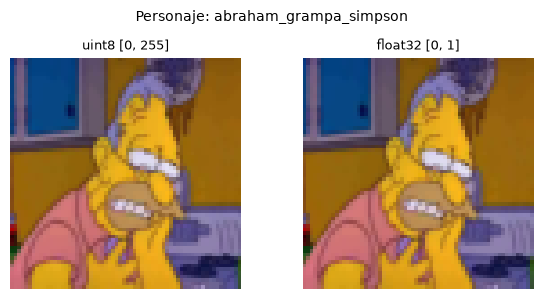

In [9]:
# La imagen normalizada debe verse identica a la original: solo cambia la escala numerica
figura, ejes = plt.subplots(1, 2, figsize=(6, 3))

ejes[0].imshow(imagenes[indice_prueba])
ejes[0].set_title("uint8 [0, 255]", fontsize=9)
ejes[1].imshow(imagenes_norm[indice_prueba])
ejes[1].set_title("float32 [0, 1]", fontsize=9)
for eje in ejes:
    eje.axis("off")

figura.suptitle(f"Personaje: {datos.iloc[indice_prueba]['personaje']}", fontsize=10)
plt.tight_layout()
plt.show()


### Vectorización (aplanado) de las imágenes

**Por que aplanar y que implica**

Una capa densa (`Dense`) recibe un vector: cada neurona se conecta con **todas** las entradas mediante
un peso. No tiene forma de aprovechar que dos pixeles esten uno al lado del otro, porque en su interior
todas las entradas son intercambiables. Por eso la imagen de `alto x ancho x 3` debe convertirse en un
unico vector de longitud fija `alto * ancho * 3`.

Con el tamano elegido en "Redimensionado a un tamano fijo" esto da **64 x 64 x 3 = 12 288** valores por imagen, que es exactamente la
dimension de la capa de entrada del MLP.

El aplanado es el paso donde se **pierde la estructura espacial**: el modelo ya no sabe que el pixel
`(0, 0)` y el `(0, 1)` eran vecinos. Esta es precisamente la limitacion que se discute en "Limitaciones del MLP en imagenes y propuestas de mejora"
y el motivo por el que una CNN, que si preserva esa vecindad, resulta mas adecuada para imagenes.



**Por que `X` tiene dos dimensiones e `y` solo una**

`X` es una **matriz**: una fila por imagen y una columna por caracteristica de entrada. Su forma
`(16137, 12288)` se lee como "16 137 ejemplos, cada uno descrito por 12 288 numeros". La primera
dimension siempre cuenta ejemplos y la segunda las caracteristicas de cada uno; es el formato que Keras
espera para alimentar una capa densa, que procesa las filas por lotes (batches).

`y` es un **vector**: su forma `(16137,)` significa "16 137 etiquetas", una por fila de `X`. Para
describir a que personaje corresponde una imagen basta con un unico numero (el indice de la clase), asi
que no hace falta una segunda dimension. Lo unico imprescindible es que `X.shape[0] == y.shape[0]` y que
el orden coincida: la etiqueta `y[i]` corresponde a la imagen `X[i]`.

Esa asimetria es solo del estado actual de los datos, no una regla: en "Codificacion de las etiquetas"
se aplicara one-hot encoding y `y` pasara a ser tambien una matriz `(16137, 25)`, con una columna por
personaje, que es lo que exige la perdida `categorical_crossentropy`.

El orden del aplanado es `C` (por filas: fila a fila, y dentro de cada fila los tres canales RGB de cada
pixel). Lo importante no es el orden concreto, sino que sea **el mismo para todas las imagenes** y para
los conjuntos de train y test, cosa que `reshape` garantiza al aplicarse sobre el arreglo completo.


In [10]:
# Cada imagen (alto, ancho, 3) pasa a ser un vector de alto * ancho * 3 valores
DIMENSION_ENTRADA = ALTO_OBJETIVO * ANCHO_OBJETIVO * 3

X = imagenes_norm.reshape(imagenes_norm.shape[0], -1)
y = etiquetas

print(f"X: {X.shape}  dtype={X.dtype}")
print(f"y: {y.shape}")
print(f"Dimension de la capa de entrada: {DIMENSION_ENTRADA}")
print(f"rango de X: [{X.min():.3f}, {X.max():.3f}]")


X: (16137, 12288)  dtype=float32
y: (16137,)
Dimension de la capa de entrada: 12288
rango de X: [0.000, 1.000]


**Comprobacion del aplanado**

In [11]:
# El aplanado debe ser reversible: recuperar la imagen original desde su vector
imagen_reconstruida = X[indice_prueba].reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3)

comprobaciones_aplanado = pd.DataFrame(
    [
        (
            "Numero de imagenes",
            X.shape[0],
            imagenes_norm.shape[0],
            X.shape[0] == imagenes_norm.shape[0],
        ),
        (
            "Longitud del vector",
            X.shape[1],
            DIMENSION_ENTRADA,
            X.shape[1] == DIMENSION_ENTRADA,
        ),
        ("Numero de dimensiones", X.ndim, 2, X.ndim == 2),
        ("Tipo de dato", str(X.dtype), "float32", X.dtype == np.float32),
        (
            "Rango conservado [0, 1]",
            f"[{X.min():.3f}, {X.max():.3f}]",
            "[0.0, 1.0]",
            bool(X.min() >= 0.0 and X.max() <= 1.0),
        ),
        (
            "Aplanado reversible",
            "X[i].reshape(alto, ancho, 3)",
            "imagenes_norm[i]",
            np.array_equal(imagen_reconstruida, imagenes_norm[indice_prueba]),
        ),
        ("Etiquetas alineadas", len(y), X.shape[0], len(y) == X.shape[0]),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_aplanado)

if not comprobaciones_aplanado["Correcto"].all():
    raise ValueError("El aplanado no cumple alguna de las comprobaciones.")

print("Aplanado verificado correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Numero de imagenes,16137,16137,True
1,Longitud del vector,12288,12288,True
2,Numero de dimensiones,2,2,True
3,Tipo de dato,float32,float32,True
4,"Rango conservado [0, 1]","[0.000, 1.000]","[0.0, 1.0]",True
5,Aplanado reversible,"X[i].reshape(alto, ancho, 3)",imagenes_norm[i],True
6,Etiquetas alineadas,16137,16137,True


Aplanado verificado correctamente.


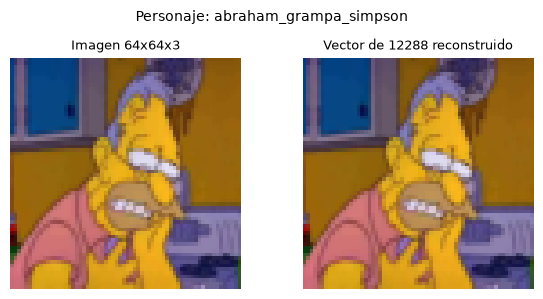

In [12]:
# Al reconstruir el vector se recupera exactamente la misma imagen
figura, ejes = plt.subplots(1, 2, figsize=(6, 3))

ejes[0].imshow(imagenes_norm[indice_prueba])
ejes[0].set_title(f"Imagen {ALTO_OBJETIVO}x{ANCHO_OBJETIVO}x3", fontsize=9)
ejes[0].axis("off")

ejes[1].imshow(imagen_reconstruida)
ejes[1].set_title(f"Vector de {DIMENSION_ENTRADA} reconstruido", fontsize=9)
ejes[1].axis("off")

figura.suptitle(f"Personaje: {datos.iloc[indice_prueba]['personaje']}", fontsize=10)
plt.tight_layout()
plt.show()


### Codificación de las etiquetas

_Mapear los 25 nombres de personaje a índices enteros y aplicar one-hot encoding, coherente con la función de pérdida categorical_crossentropy._

**De nombre de carpeta a vector one-hot**

Las etiquetas nacen como texto (el nombre de la carpeta, por ejemplo `homer_simpson`) y una red no opera
con texto, asi que hay que convertirlas a numeros. La conversion se hace en dos pasos:

1. **Indice entero.** Ya se construyo en "Carga de imagenes y etiquetas": `clases` es la lista de
   personajes ordenada alfabeticamente y `clase_a_indice` asigna a cada uno un entero de 0 a 24. Ese
   mapeo se reutiliza aqui en lugar de recalcularlo, porque debe ser **identico en train y en test**: si
   el indice 3 significara un personaje distinto en cada conjunto, la evaluacion no tendria sentido.

2. **One-hot encoding.** El indice entero por si solo es enganoso para el modelo: sugiere un **orden** y
   una **distancia** que no existen (que la clase 5 este "entre" la 4 y la 6, o que la 24 sea "mayor" que
   la 1). Los personajes son categorias nominales, sin orden. El one-hot elimina ese artefacto
   representando cada etiqueta como un vector de 25 posiciones con un 1 en la clase correcta y 0 en el
   resto, de modo que todas las clases quedan a la misma distancia entre si.

Ademas, esta forma es la que corresponde a la salida de la red: la capa final tiene 25 neuronas con
`softmax`, que produce un vector de 25 probabilidades. La perdida `categorical_crossentropy` compara ese
vector con el one-hot real, penalizando la probabilidad asignada a la clase verdadera.

> Existe la alternativa de dejar `y` como enteros y usar `sparse_categorical_crossentropy`, que es
> equivalente y ahorra memoria. Aqui se usa one-hot explicito porque hace visible la correspondencia con
> las 25 neuronas de salida, que es justamente lo que interesa mostrar en este trabajo.


In [13]:
NUMERO_CLASES = len(clases)

# One-hot: la fila i de la matriz identidad es el vector con un 1 en la posicion i
# Equivale a keras.utils.to_categorical(y, NUMERO_CLASES), sin cargar TensorFlow todavia
y_onehot = np.eye(NUMERO_CLASES, dtype=np.float32)[y]

print(f"Numero de clases: {NUMERO_CLASES}")
print(f"y (indices):  {y.shape}  dtype={y.dtype}")
print(f"y_onehot:     {y_onehot.shape}  dtype={y_onehot.dtype}")

# Correspondencia para una imagen concreta
posicion_activa = int(y_onehot[indice_prueba].argmax())
print(
    f"\nEjemplo (imagen {indice_prueba}): '{datos.iloc[indice_prueba]['personaje']}'"
    f" -> indice {y[indice_prueba]} -> posicion activa {posicion_activa}"
)
print(f"vector one-hot: {y_onehot[indice_prueba].astype(int)}")


Numero de clases: 25
y (indices):  (16137,)  dtype=int64
y_onehot:     (16137, 25)  dtype=float32

Ejemplo (imagen 0): 'abraham_grampa_simpson' -> indice 0 -> posicion activa 0
vector one-hot: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Comprobacion de la codificacion**

In [14]:
comprobaciones_etiquetas = pd.DataFrame(
    [
        (
            "Numero de ejemplos",
            y_onehot.shape[0],
            X.shape[0],
            y_onehot.shape[0] == X.shape[0],
        ),
        (
            "Columnas = numero de clases",
            y_onehot.shape[1],
            NUMERO_CLASES,
            y_onehot.shape[1] == NUMERO_CLASES,
        ),
        ("Tipo de dato", str(y_onehot.dtype), "float32", y_onehot.dtype == np.float32),
        (
            "Un unico 1 por fila",
            float(y_onehot.sum(axis=1).min()),
            1.0,
            bool(np.all(y_onehot.sum(axis=1) == 1.0)),
        ),
        (
            "Solo valores 0 o 1",
            sorted(np.unique(y_onehot).tolist()),
            [0.0, 1.0],
            bool(np.isin(np.unique(y_onehot), [0.0, 1.0]).all()),
        ),
        (
            "Coincide con el indice entero",
            "y_onehot.argmax(axis=1)",
            "y",
            bool(np.array_equal(y_onehot.argmax(axis=1), y)),
        ),
        (
            "Todas las clases presentes",
            int((y_onehot.sum(axis=0) > 0).sum()),
            NUMERO_CLASES,
            int((y_onehot.sum(axis=0) > 0).sum()) == NUMERO_CLASES,
        ),
        (
            "Mapeo estable (indice -> nombre)",
            indice_a_clase[0],
            clases[0],
            indice_a_clase[0] == clases[0],
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_etiquetas)

if not comprobaciones_etiquetas["Correcto"].all():
    raise ValueError("La codificacion de etiquetas no cumple alguna de las comprobaciones.")

print("Codificacion verificada correctamente.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Numero de ejemplos,16137,16137,True
1,Columnas = numero de clases,25,25,True
2,Tipo de dato,float32,float32,True
3,Un unico 1 por fila,1.0,1.0,True
4,Solo valores 0 o 1,"[0.0, 1.0]","[0.0, 1.0]",True
5,Coincide con el indice entero,y_onehot.argmax(axis=1),y,True
6,Todas las clases presentes,25,25,True
7,Mapeo estable (indice -> nombre),abraham_grampa_simpson,abraham_grampa_simpson,True


Codificacion verificada correctamente.


In [15]:
# Diccionario de clases: indice, nombre y ejemplos disponibles
tabla_clases = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "imagenes": [int((y == indice).sum()) for indice in range(NUMERO_CLASES)],
    }
)
tabla_clases["porcentaje"] = (tabla_clases["imagenes"] / len(y) * 100).round(2)

display(tabla_clases)


,indice,personaje,imagenes,porcentaje
0,0,abraham_grampa_simpson,730,4.52
1,1,apu_nahasapeemapetilon,498,3.09
2,2,barney_gumble,84,0.52
3,3,bart_simpson,1073,6.65
4,4,charles_montgomery_burns,954,5.91
5,5,chief_wiggum,788,4.88
6,6,comic_book_guy,375,2.32
7,7,edna_krabappel,365,2.26
8,8,groundskeeper_willie,96,0.59
9,9,homer_simpson,1796,11.13


### Partición train / validación

_Separar de forma estratificada una porción del conjunto de entrenamiento como validación. El conjunto test se reserva exclusivamente para la evaluación final._

**Por que hacen falta tres conjuntos y no dos**

El dataset ya viene dividido en `train` y `test`, pero entrenar mirando el test es hacer trampa: en
cuanto se usa para decidir cuantas capas poner, cuando detener el entrenamiento o que learning rate
elegir, deja de ser una estimacion honesta del desempeno con datos nuevos, porque esas decisiones ya lo
incorporaron. Ese fenomeno se conoce como fuga de informacion.

Por eso el conjunto de entrenamiento se parte en dos:

- **Entrenamiento (80 %):** las imagenes con las que se ajustan los pesos.
- **Validacion (20 %):** imagenes que nunca actualizan pesos, pero que se miden en cada epoca. Sirven
  para trazar las curvas de aprendizaje, detectar sobreajuste, activar `EarlyStopping` y comparar las
  configuraciones de la experimentacion.
- **Test:** se reserva intacto y se abre **una sola vez**, en la evaluacion final del modelo elegido.

**Particion estratificada.** Se usa `stratify=y` para que cada clase conserve en train y en validacion la
misma proporcion que tiene en el conjunto completo. Con clases muy desbalanceadas, un reparto aleatorio
simple podria dejar a un personaje minoritario con muy pocos ejemplos de validacion -- o con ninguno --,
y entonces su metrica seria pura casualidad. La estratificacion tambien hace que la validacion sea
comparable entre experimentos.

**Semilla fija.** `random_state=SEMILLA` garantiza que la particion sea siempre la misma. Es un requisito
de la metodologia de experimentacion: al cambiar un solo factor por vez, la diferencia observada debe
deberse a ese factor y no a que le toco un reparto de datos distinto.


In [16]:
from sklearn.model_selection import train_test_split

SEMILLA = 42
PROPORCION_VALIDACION = 0.2

if conjunto != "train":
    raise RuntimeError(
        'La particion train/validacion solo se aplica al conjunto "train". '
        f'Actualmente esta seleccionado "{conjunto}" en la primera celda del notebook.'
    )

# Se reparten a la vez las tres estructuras para que queden alineadas:
# X (vectores), y_onehot (etiquetas para la red) y y (indices, comodos para analizar)
X_train, X_val, y_train, y_val, y_train_idx, y_val_idx = train_test_split(
    X,
    y_onehot,
    y,
    test_size=PROPORCION_VALIDACION,
    stratify=y,  # conserva la proporcion de cada personaje en ambas partes
    random_state=SEMILLA,
    shuffle=True,
)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(
    f"\nReparto: {len(X_train)} entrenamiento ({len(X_train) / len(X) * 100:.1f} %)"
    f" / {len(X_val)} validacion ({len(X_val) / len(X) * 100:.1f} %)"
)
print(f"Memoria aproximada: {(X_train.nbytes + X_val.nbytes) / 1024 ** 3:.2f} GB")


X_train: (12909, 12288)   y_train: (12909, 25)
X_val:   (3228, 12288)   y_val:   (3228, 25)

Reparto: 12909 entrenamiento (80.0 %) / 3228 validacion (20.0 %)
Memoria aproximada: 0.74 GB


**Comprobacion de la particion**

In [17]:
# Proporcion de cada clase en el conjunto completo frente a train y validacion
proporciones = pd.DataFrame(
    {
        "personaje": clases,
        "completo_%": [round((y == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "train_%": [round((y_train_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "val_%": [round((y_val_idx == i).mean() * 100, 2) for i in range(NUMERO_CLASES)],
        "n_train": [int((y_train_idx == i).sum()) for i in range(NUMERO_CLASES)],
        "n_val": [int((y_val_idx == i).sum()) for i in range(NUMERO_CLASES)],
    }
)
proporciones["desviacion_%"] = (proporciones["val_%"] - proporciones["completo_%"]).abs().round(2)

display(proporciones)

comprobaciones_particion = pd.DataFrame(
    [
        (
            "Sin perdida de ejemplos",
            len(X_train) + len(X_val),
            len(X),
            len(X_train) + len(X_val) == len(X),
        ),
        (
            "Dimension de entrada intacta",
            X_train.shape[1],
            DIMENSION_ENTRADA,
            X_train.shape[1] == DIMENSION_ENTRADA,
        ),
        ("X e y alineados en train", len(y_train), len(X_train), len(y_train) == len(X_train)),
        ("X e y alineados en validacion", len(y_val), len(X_val), len(y_val) == len(X_val)),
        (
            "One-hot coherente con indices",
            "y_val.argmax(axis=1)",
            "y_val_idx",
            bool(np.array_equal(y_val.argmax(axis=1), y_val_idx)),
        ),
        (
            "Todas las clases en train",
            int(len(np.unique(y_train_idx))),
            NUMERO_CLASES,
            len(np.unique(y_train_idx)) == NUMERO_CLASES,
        ),
        (
            "Todas las clases en validacion",
            int(len(np.unique(y_val_idx))),
            NUMERO_CLASES,
            len(np.unique(y_val_idx)) == NUMERO_CLASES,
        ),
        (
            "Estratificacion (desviacion maxima)",
            f"{proporciones['desviacion_%'].max():.2f} %",
            "< 1 %",
            bool(proporciones["desviacion_%"].max() < 1.0),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_particion)

if not comprobaciones_particion["Correcto"].all():
    raise ValueError("La particion no cumple alguna de las comprobaciones.")

print("Particion verificada correctamente.")


,personaje,completo_%,train_%,val_%,n_train,n_val,desviacion_%
0,abraham_grampa_simpson,4.52,4.52,4.52,584,146,0.00
1,apu_nahasapeemapetilon,3.09,3.08,3.10,398,100,0.01
2,barney_gumble,0.52,0.52,0.53,67,17,0.01
3,bart_simpson,6.65,6.65,6.66,858,215,0.01
4,charles_montgomery_burns,5.91,5.91,5.92,763,191,0.01
5,chief_wiggum,4.88,4.88,4.89,630,158,0.01
6,comic_book_guy,2.32,2.32,2.32,300,75,0.00
7,edna_krabappel,2.26,2.26,2.26,292,73,0.00
8,groundskeeper_willie,0.59,0.60,0.59,77,19,0.00
9,homer_simpson,11.13,11.13,11.12,1437,359,0.01


,Comprobacion,Obtenido,Esperado,Correcto
0,Sin perdida de ejemplos,16137,16137,True
1,Dimension de entrada intacta,12288,12288,True
2,X e y alineados en train,12909,12909,True
3,X e y alineados en validacion,3228,3228,True
4,One-hot coherente con indices,y_val.argmax(axis=1),y_val_idx,True
5,Todas las clases en train,25,25,True
6,Todas las clases en validacion,25,25,True
7,Estratificacion (desviacion maxima),0.02 %,< 1 %,True


Particion verificada correctamente.


### Tratamiento del desbalance de clases

_Dado el desbalance descrito en "Definición del problema de clasificación" (razón aproximada 22:1), se evaluará el uso de pesos por clase (class_weight) y/o aumento de datos sobre las clases minoritarias, documentando el efecto de la decisión._

**El problema**

Como se describio en "Definicion del problema de clasificacion", las clases estan muy desbalanceadas
(razon aproximada 22:1 entre el personaje mas y el menos frecuente). Esto sesga el entrenamiento: la
perdida es un promedio sobre los ejemplos del batch, asi que los personajes abundantes dominan el
gradiente y el modelo aprende que, ante la duda, conviene predecir una clase mayoritaria. El resultado
tipico es un accuracy global aceptable acompanado de un recall muy bajo en las clases pequenas, que es
precisamente lo que el **F1 macro** -- promedio no ponderado entre clases -- deja al descubierto.

**Opciones consideradas**

| Estrategia | Que hace | Por que se descarta o se elige |
|---|---|---|
| Submuestreo de mayoritarias | Elimina imagenes de las clases grandes | Se descarta: tira informacion util y el dataset ya es modesto |
| Sobremuestreo por duplicado | Repite imagenes de las clases pequenas | Se descarta: los duplicados exactos favorecen el sobreajuste a esas imagenes |
| Aumento de datos | Genera variantes (giros, recortes, brillo) | Util, pero encarece el entrenamiento; se deja como propuesta de mejora |
| **Pesos por clase** | Pondera la perdida segun la frecuencia de cada clase | **Se elige:** no altera los datos, es una linea de codigo y actua justo donde esta el sesgo |

**Como funciona `class_weight`.** Keras multiplica la perdida de cada ejemplo por el peso de su clase, de
modo que equivocarse en un personaje raro cuesta mas que equivocarse en uno frecuente. Se usa la formula
`n_muestras / (n_clases * n_ejemplos_de_la_clase)`, que da peso 1 a una clase de tamano medio, mayor que 1
a las minoritarias y menor que 1 a las mayoritarias.

**Advertencia importante.** Los pesos se calculan **solo con `y_train`**, nunca con el conjunto completo
ni con validacion: usar informacion de validacion para ajustar el entrenamiento seria otra forma de fuga.
Y se aplican **solo durante el entrenamiento**: las metricas de validacion y test se miden sin pesos,
porque deben reflejar el desempeno sobre la distribucion real de los datos.

El efecto de esta decision se contrasta en la experimentacion, comparando el modelo base con y sin
`class_weight` mediante el accuracy y el F1 macro de validacion.


In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Los pesos se calculan SOLO con las etiquetas de entrenamiento
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUMERO_CLASES),
    y=y_train_idx,
)

# Keras espera un diccionario {indice_de_clase: peso}
pesos_por_clase = {indice: float(peso) for indice, peso in enumerate(pesos)}

conteos_train = np.bincount(y_train_idx, minlength=NUMERO_CLASES)

tabla_pesos = pd.DataFrame(
    {
        "indice": range(NUMERO_CLASES),
        "personaje": clases,
        "n_train": conteos_train,
        "porcentaje": (conteos_train / conteos_train.sum() * 100).round(2),
        "peso": np.round(pesos, 3),
    }
).sort_values("n_train", ascending=False, ignore_index=True)

display(tabla_pesos)

razon_desbalance = conteos_train.max() / conteos_train.min()
print(f"Clase mayoritaria: {clases[int(conteos_train.argmax())]} ({conteos_train.max()} imagenes)")
print(f"Clase minoritaria: {clases[int(conteos_train.argmin())]} ({conteos_train.min()} imagenes)")
print(f"Razon de desbalance: {razon_desbalance:.1f}:1")
print(f"Rango de pesos: [{pesos.min():.3f}, {pesos.max():.3f}]")


,indice,personaje,n_train,porcentaje,peso
0,9,homer_simpson,1437,11.13,0.359
1,19,ned_flanders,930,7.20,0.555
2,18,moe_szyslak,929,7.20,0.556
3,13,lisa_simpson,866,6.71,0.596
4,3,bart_simpson,858,6.65,0.602
5,15,marge_simpson,826,6.40,0.625
6,11,krusty_the_clown,771,5.97,0.670
7,21,principal_skinner,764,5.92,0.676
8,4,charles_montgomery_burns,763,5.91,0.677
9,17,milhouse_van_houten,690,5.35,0.748


Clase mayoritaria: homer_simpson (1437 imagenes)
Clase minoritaria: selma_bouvier (66 imagenes)
Razon de desbalance: 21.8:1
Rango de pesos: [0.359, 7.824]


**Comprobacion de los pesos y baselines de referencia**

In [19]:
comprobaciones_pesos = pd.DataFrame(
    [
        (
            "Un peso por clase",
            len(pesos_por_clase),
            NUMERO_CLASES,
            len(pesos_por_clase) == NUMERO_CLASES,
        ),
        (
            "Todos los pesos positivos",
            round(float(pesos.min()), 3),
            "> 0",
            bool((pesos > 0).all()),
        ),
        (
            "Mayor peso a la clase minoritaria",
            clases[int(pesos.argmax())],
            clases[int(conteos_train.argmin())],
            int(pesos.argmax()) == int(conteos_train.argmin()),
        ),
        (
            "Menor peso a la clase mayoritaria",
            clases[int(pesos.argmin())],
            clases[int(conteos_train.argmax())],
            int(pesos.argmin()) == int(conteos_train.argmax()),
        ),
        (
            "Peso inverso a la frecuencia",
            "corr(peso, n_train)",
            "negativa",
            bool(float(np.corrcoef(pesos, conteos_train)[0, 1]) < 0),
        ),
        (
            "Calculados solo con train",
            len(y_train_idx),
            len(X_train),
            len(y_train_idx) == len(X_train),
        ),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_pesos)

if not comprobaciones_pesos["Correcto"].all():
    raise ValueError("Los pesos por clase no cumplen alguna de las comprobaciones.")

# Baselines contra los que se comparara el modelo final
baseline_azar = 100 / NUMERO_CLASES
baseline_mayoritaria = conteos_train.max() / conteos_train.sum() * 100

print(f"\nBaseline por azar (1/{NUMERO_CLASES}): {baseline_azar:.1f} % de accuracy")
print(f"Baseline de clase mayoritaria:  {baseline_mayoritaria:.1f} % de accuracy")
print("El modelo solo aporta valor si supera claramente ambos.")


,Comprobacion,Obtenido,Esperado,Correcto
0,Un peso por clase,25,25,True
1,Todos los pesos positivos,0.359,> 0,True
2,Mayor peso a la clase minoritaria,selma_bouvier,selma_bouvier,True
3,Menor peso a la clase mayoritaria,homer_simpson,homer_simpson,True
4,Peso inverso a la frecuencia,"corr(peso, n_train)",negativa,True
5,Calculados solo con train,12909,12909,True



Baseline por azar (1/25): 4.0 % de accuracy
Baseline de clase mayoritaria:  11.1 % de accuracy
El modelo solo aporta valor si supera claramente ambos.


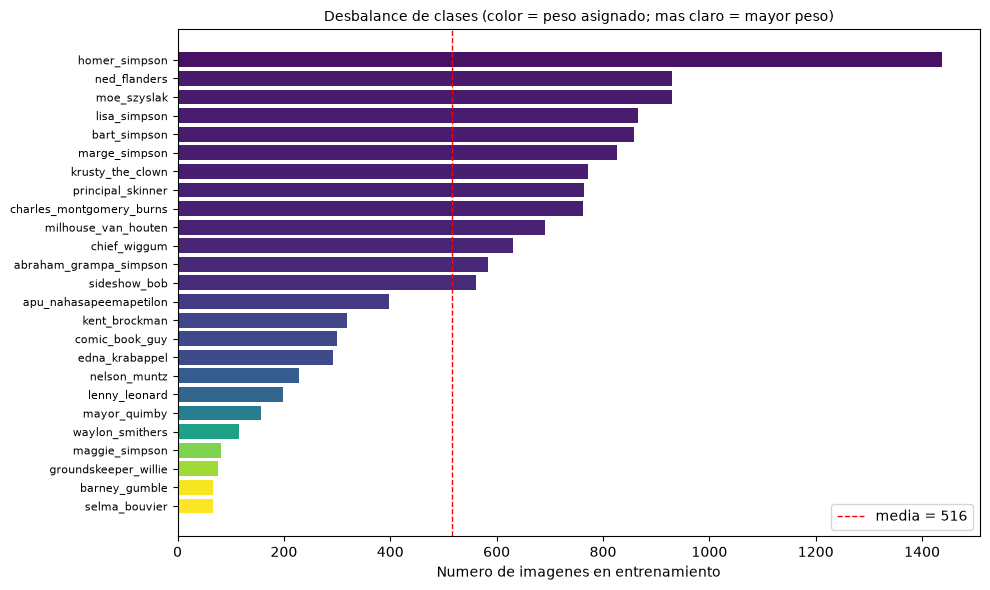

In [20]:
import matplotlib

# Distribucion de imagenes por personaje en el conjunto de entrenamiento
figura, eje = plt.subplots(figsize=(10, 6))

orden = np.argsort(conteos_train)
eje.barh(
    [clases[i] for i in orden],
    conteos_train[orden],
    color=matplotlib.colormaps["viridis"](pesos[orden] / pesos.max()),
)
eje.set_xlabel("Numero de imagenes en entrenamiento")
eje.set_title("Desbalance de clases (color = peso asignado; mas claro = mayor peso)", fontsize=10)
eje.tick_params(axis="y", labelsize=8)
eje.axvline(
    conteos_train.mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"media = {conteos_train.mean():.0f}",
)
eje.legend()

plt.tight_layout()
plt.show()


## Fundamentos: estructura de una red neuronal profunda

_Descripción teórica, apoyada en el material del curso, de los componentes que conforman la red que se implementa en la sección siguiente._

### Capas y neuronas

_Capa de entrada (dimensionada por el vector de la imagen aplanada), capas ocultas densas y capa de salida con una neurona por clase. Rol de cada una en el flujo de información._

**Que es una neurona**

La unidad basica de la red es la neurona artificial, inspirada de forma muy simplificada en la neurona
biologica: recibe varias senales de entrada, las combina dando mas importancia a unas que a otras y
produce una unica senal de salida. Toda su "inteligencia" esta en esos pesos, que son numeros que se
ajustan durante el entrenamiento.

**Como se organizan en capas**

Las neuronas no trabajan sueltas, sino agrupadas en capas, y cada capa recibe como entrada la salida de
la anterior. Una red **densa** o *fully connected* es aquella en la que cada neurona de una capa se
conecta con **todas** las neuronas de la capa siguiente. Un Perceptron Multicapa es exactamente eso:
una pila de capas densas.

| Capa | Papel en la red | En este proyecto |
|---|---|---|
| **Entrada** | No calcula nada; solo define la forma del dato que entra | 12 288 valores (el vector de 64x64x3 del pre-procesamiento) |
| **Ocultas** | Transforman progresivamente la entrada en representaciones mas utiles para separar las clases | Una o varias capas densas con activacion ReLU |
| **Salida** | Produce la prediccion en el formato del problema | 25 neuronas con softmax, una por personaje |

**Por que "profunda" y que aprenden las capas ocultas**

Se llama profunda a una red con mas de una capa oculta. La idea es que la composicion de capas construye
una **jerarquia de representaciones**: la primera capa detecta patrones muy simples a partir de los
pixeles (zonas de color, contrastes), y cada capa posterior combina los patrones de la anterior en
conceptos mas abstractos que, idealmente, terminan siendo caracteristicas discriminantes entre
personajes. Ninguna de esas caracteristicas se programa: emergen del ajuste de los pesos.

Se las llama "ocultas" simplemente porque no se observan desde fuera; solo vemos lo que entra y lo que
sale de la red.

**Ancho, profundidad y su costo**

Dos decisiones de diseno definen la arquitectura:

- **Profundidad** (cuantas capas ocultas): mas capas permiten representar funciones mas complejas, pero
  dificultan el entrenamiento y aumentan el riesgo de sobreajuste.
- **Ancho** (cuantas neuronas por capa): mas neuronas dan mas capacidad a cada nivel, a costa de muchos
  mas parametros.

Ese costo no es menor en nuestro caso. Como la entrada tiene 12 288 valores y la conexion es total, la
primera capa oculta concentra la enorme mayoria de los parametros del modelo. La siguiente celda lo
cuantifica.


In [21]:
# Cuantos parametros implica cada eleccion de ancho en la primera capa oculta
anchos_posibles = [64, 128, 256, 512, 1024]

tabla_costo = pd.DataFrame(
    {
        "neuronas_capa_1": anchos_posibles,
        # pesos (entrada x neuronas) + un sesgo por neurona
        "parametros_capa_1": [DIMENSION_ENTRADA * n + n for n in anchos_posibles],
    }
)
tabla_costo["parametros_salida"] = [n * NUMERO_CLASES + NUMERO_CLASES for n in anchos_posibles]
tabla_costo["total"] = tabla_costo["parametros_capa_1"] + tabla_costo["parametros_salida"]
tabla_costo["% en capa 1"] = (
    tabla_costo["parametros_capa_1"] / tabla_costo["total"] * 100
).round(1)
tabla_costo["memoria_MB"] = (tabla_costo["total"] * 4 / 1024 ** 2).round(1)

display(tabla_costo)

print(f"Dimension de entrada: {DIMENSION_ENTRADA} valores")
print(f"Neuronas de salida:   {NUMERO_CLASES} (una por personaje)")
print(
    "\nLa primera capa oculta concentra casi todos los parametros: es la unica"
    "\nque se conecta con los 12 288 pixeles del vector de entrada."
)


,neuronas_capa_1,parametros_capa_1,parametros_salida,total,% en capa 1,memoria_MB
0,64,786496,1625,788121,99.8,3.0
1,128,1572992,3225,1576217,99.8,6.0
2,256,3145984,6425,3152409,99.8,12.0
3,512,6291968,12825,6304793,99.8,24.1
4,1024,12583936,25625,12609561,99.8,48.1


Dimension de entrada: 12288 valores
Neuronas de salida:   25 (una por personaje)

La primera capa oculta concentra casi todos los parametros: es la unica
que se conecta con los 12 288 pixeles del vector de entrada.


### Pesos, sesgos y propagación hacia adelante

_Cómo cada neurona calcula una combinación lineal de sus entradas más un sesgo, y por qué esos parámetros son exactamente lo que el modelo aprende._

**El calculo de una neurona**

Cada neurona hace siempre lo mismo, en dos pasos:

1. **Combinacion lineal (preactivacion).** Multiplica cada entrada por su peso, suma todo y anade el
   sesgo:

   $$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

2. **Activacion.** Pasa ese numero por una funcion no lineal: $a = f(z)$.

**Que significan los pesos y el sesgo**

- El **peso** $w_i$ mide cuanto influye la entrada $x_i$ en esta neurona. Un peso grande y positivo
  indica que esa entrada empuja a la neurona a activarse; uno negativo, que la inhibe; uno cercano a cero,
  que esa entrada le resulta irrelevante. En nuestro caso cada peso de la primera capa esta asociado a un
  canal de color de un pixel concreto.
- El **sesgo** $b$ desplaza el umbral de activacion. Sin el, toda neurona estaria obligada a dar 0 cuando
  la entrada es 0, y todas las fronteras de decision tendrian que pasar por el origen. El sesgo le da
  libertad para activarse aun con entradas debiles, o para exigir una evidencia mayor.

**Pesos y sesgos son lo que el modelo aprende.** Todo lo demas -- numero de capas, neuronas, activaciones,
learning rate -- lo fijamos nosotros antes de entrenar y por eso se llaman hiperparametros. Los parametros
propiamente dichos son estos numeros, que empiezan con valores aleatorios pequenos y se van corrigiendo.

**De una neurona a una capa: forma matricial**

Escribir el calculo neurona por neurona seria impracticable. Como todas las neuronas de una capa hacen la
misma operacion sobre la misma entrada, se agrupan sus pesos en una matriz $W$ y sus sesgos en un vector
$\mathbf{b}$, y la capa entera se calcula de un golpe:

$$\mathbf{a}^{(l)} = f\left(\mathbf{a}^{(l-1)} W^{(l)} + \mathbf{b}^{(l)}\right)$$

Esto no es solo notacion elegante: es lo que permite procesar un **batch** completo de imagenes en una
sola multiplicacion de matrices, que es justo la operacion que GPU y CPU ejecutan de forma optimizada.

**Propagacion hacia adelante (forward pass)**

Se llama asi al recorrido completo: la imagen entra como vector, cada capa aplica su transformacion y
pasa el resultado a la siguiente, hasta que la capa de salida produce las 25 probabilidades. Es lo que
ocurre cada vez que el modelo predice, y tambien el primer paso de cada iteracion de entrenamiento: sin
saber que predijo la red no se puede medir cuanto se equivoco.

La celda siguiente reproduce ese recorrido a mano con NumPy, sobre una imagen real del dataset, para ver
las formas de cada matriz y comprobar que la salida es una distribucion de probabilidad.


In [22]:
# Forward pass "a mano" con una arquitectura minima: 12288 -> 64 -> 25
generador_pesos = np.random.default_rng(SEMILLA)
NEURONAS_DEMO = 64


def inicializar_capa(entradas, neuronas):
    """Pesos pequenos aleatorios (escala de He, la que usa Keras con ReLU) y sesgos a cero."""
    W = generador_pesos.normal(0, np.sqrt(2 / entradas), size=(entradas, neuronas)).astype(np.float32)
    b = np.zeros(neuronas, dtype=np.float32)
    return W, b


W1, b1 = inicializar_capa(DIMENSION_ENTRADA, NEURONAS_DEMO)
W2, b2 = inicializar_capa(NEURONAS_DEMO, NUMERO_CLASES)

# Una imagen real del conjunto de entrenamiento
entrada = X_train[0]

# Capa oculta: combinacion lineal + ReLU
z1 = entrada @ W1 + b1
a1 = np.maximum(0, z1)

# Capa de salida: combinacion lineal + softmax (se resta el maximo por estabilidad numerica)
z2 = a1 @ W2 + b2
exponenciales = np.exp(z2 - z2.max())
salida = exponenciales / exponenciales.sum()

recorrido = pd.DataFrame(
    [
        ("entrada (imagen aplanada)", str(entrada.shape), entrada.size),
        ("W1 (pesos capa oculta)", str(W1.shape), W1.size),
        ("b1 (sesgos capa oculta)", str(b1.shape), b1.size),
        ("z1 = entrada @ W1 + b1", str(z1.shape), z1.size),
        ("a1 = ReLU(z1)", str(a1.shape), a1.size),
        ("W2 (pesos capa salida)", str(W2.shape), W2.size),
        ("b2 (sesgos capa salida)", str(b2.shape), b2.size),
        ("z2 = a1 @ W2 + b2", str(z2.shape), z2.size),
        ("salida = softmax(z2)", str(salida.shape), salida.size),
    ],
    columns=["Paso", "Forma", "Numero de valores"],
)

display(recorrido)

print(f"Parametros entrenables de esta red minima: {W1.size + b1.size + W2.size + b2.size:,}")


,Paso,Forma,Numero de valores
0,entrada (imagen aplanada),"(12288,)",12288
1,W1 (pesos capa oculta),"(12288, 64)",786432
2,b1 (sesgos capa oculta),"(64,)",64
3,z1 = entrada @ W1 + b1,"(64,)",64
4,a1 = ReLU(z1),"(64,)",64
5,W2 (pesos capa salida),"(64, 25)",1600
6,b2 (sesgos capa salida),"(25,)",25
7,z2 = a1 @ W2 + b2,"(25,)",25
8,salida = softmax(z2),"(25,)",25


Parametros entrenables de esta red minima: 788,121


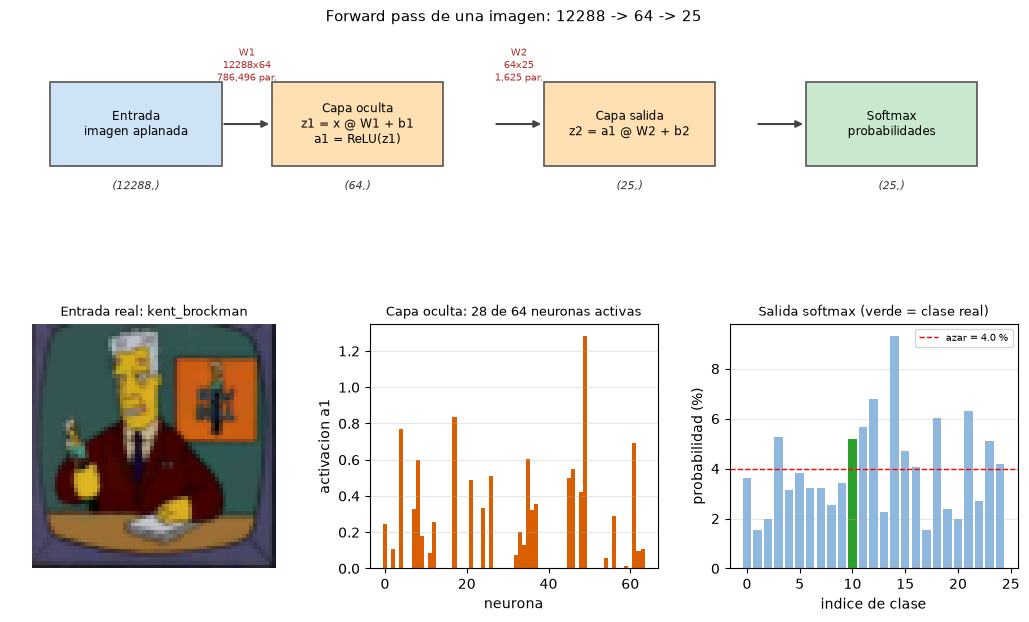

Sin entrenar, la red predice 'maggie_simpson' con 9.3 % de confianza, cuando la clase real es 'kent_brockman', a la que asigna solo 5.2 %.
El reparto responde unicamente a los pesos aleatorios, no a la imagen: la referencia de azar es 4.0 %.
Entrenar consiste en ajustar W1, b1, W2 y b2 para que la barra verde crezca y las demas bajen.


In [23]:
# Recorrido de la senal a traves de la red, paso a paso
figura = plt.figure(figsize=(13, 7))
malla = figura.add_gridspec(2, 3, height_ratios=[1, 1.25], hspace=0.45, wspace=0.25)

# --- Fila superior: esquema del flujo de datos con las formas de cada tensor ---
esquema = figura.add_subplot(malla[0, :])
esquema.set_xlim(0, 10)
esquema.set_ylim(0, 3)
esquema.axis("off")

bloques = [
    (0.4, "Entrada\nimagen aplanada", f"({DIMENSION_ENTRADA},)", "#cfe3f7"),
    (2.6, "Capa oculta\nz1 = x @ W1 + b1\na1 = ReLU(z1)", f"({NEURONAS_DEMO},)", "#ffe0b3"),
    (5.3, "Capa salida\nz2 = a1 @ W2 + b2", f"({NUMERO_CLASES},)", "#ffe0b3"),
    (7.9, "Softmax\nprobabilidades", f"({NUMERO_CLASES},)", "#c9e8cd"),
]

for x, texto, forma, color in bloques:
    esquema.add_patch(
        plt.Rectangle((x, 0.9), 1.7, 1.3, facecolor=color, edgecolor="#555", linewidth=1.2)
    )
    esquema.text(x + 0.85, 1.55, texto, ha="center", va="center", fontsize=8.5)
    esquema.text(x + 0.85, 0.6, forma, ha="center", va="center", fontsize=8, style="italic", color="#333")

pesos_entre = [
    (2.1, f"W1\n{W1.shape[0]}x{W1.shape[1]}\n{W1.size + b1.size:,} par."),
    (4.8, f"W2\n{W2.shape[0]}x{W2.shape[1]}\n{W2.size + b2.size:,} par."),
    (7.4, ""),
]
for x, etiqueta in pesos_entre:
    esquema.annotate(
        "",
        xy=(x + 0.5, 1.55),
        xytext=(x, 1.55),
        arrowprops=dict(arrowstyle="-|>", linewidth=1.5, color="#444"),
    )
    if etiqueta:
        esquema.text(x + 0.25, 2.45, etiqueta, ha="center", va="center", fontsize=7.5, color="#b03030")

esquema.set_title(
    f"Forward pass de una imagen: {DIMENSION_ENTRADA} -> {NEURONAS_DEMO} -> {NUMERO_CLASES}",
    fontsize=11,
)

# --- Abajo izquierda: la imagen que entra a la red ---
eje_imagen = figura.add_subplot(malla[1, 0])
eje_imagen.imshow(entrada.reshape(ALTO_OBJETIVO, ANCHO_OBJETIVO, 3))
eje_imagen.set_title(f"Entrada real: {clases[int(y_train_idx[0])]}", fontsize=9)
eje_imagen.axis("off")

# --- Abajo centro: activaciones de la capa oculta ---
eje_ocultas = figura.add_subplot(malla[1, 1])
colores_ocultas = ["#d95f02" if valor > 0 else "#bbbbbb" for valor in a1]
eje_ocultas.bar(range(NEURONAS_DEMO), a1, color=colores_ocultas, width=1.0)
eje_ocultas.set_title(
    f"Capa oculta: {(a1 > 0).sum()} de {NEURONAS_DEMO} neuronas activas", fontsize=9
)
eje_ocultas.set_xlabel("neurona")
eje_ocultas.set_ylabel("activacion a1")
eje_ocultas.grid(alpha=0.3, axis="y")

# --- Abajo derecha: distribucion de probabilidad de salida ---
eje_salida = figura.add_subplot(malla[1, 2])
clase_real = int(y_train_idx[0])
colores_salida = ["#2ca02c" if i == clase_real else "#8fb8de" for i in range(NUMERO_CLASES)]
eje_salida.bar(range(NUMERO_CLASES), salida * 100, color=colores_salida)
eje_salida.axhline(
    100 / NUMERO_CLASES,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"azar = {100 / NUMERO_CLASES:.1f} %",
)
eje_salida.set_title("Salida softmax (verde = clase real)", fontsize=9)
eje_salida.set_xlabel("indice de clase")
eje_salida.set_ylabel("probabilidad (%)")
eje_salida.legend(fontsize=7)
eje_salida.grid(alpha=0.3, axis="y")

plt.show()

print(
    f"Sin entrenar, la red predice '{clases[int(salida.argmax())]}' con {salida.max() * 100:.1f} %"
    f" de confianza, cuando la clase real es '{clases[clase_real]}', a la que asigna solo"
    f" {salida[clase_real] * 100:.1f} %."
    f"\nEl reparto responde unicamente a los pesos aleatorios, no a la imagen: la referencia de"
    f" azar es {100 / NUMERO_CLASES:.1f} %."
    "\nEntrenar consiste en ajustar W1, b1, W2 y b2 para que la barra verde crezca y las demas bajen."
)


### Funciones de activación

**Por que hace falta la no linealidad**

Si se quitaran las funciones de activacion, cada capa seria solo una multiplicacion de matrices y la red
entera colapsaria en una sola: la composicion de funciones lineales es otra funcion lineal. Una red de
diez capas sin activaciones tendria exactamente el mismo poder expresivo que una regresion lineal, y seria
incapaz de separar clases que no se puedan dividir con un hiperplano. La activacion no lineal es lo que
permite que apilar capas sirva de algo.

**Comparacion de las activaciones para las capas ocultas**

| Funcion | Formula | Rango | Ventaja | Problema |
|---|---|---|---|---|
| **Sigmoide** | $1/(1+e^{-z})$ | (0, 1) | Interpretable como probabilidad | Se satura: para $\|z\|$ grande el gradiente tiende a 0 y el aprendizaje se detiene |
| **Tanh** | $(e^z-e^{-z})/(e^z+e^{-z})$ | (-1, 1) | Centrada en cero, converge mejor que la sigmoide | Tambien se satura en los extremos |
| **ReLU** | $\max(0, z)$ | [0, inf) | Gradiente constante 1 para $z>0$: no se satura; muy barata de calcular; produce activaciones dispersas | "Neuronas muertas": si una unidad queda siempre en $z<0$, su gradiente es 0 y no vuelve a aprender |

**Eleccion: ReLU en las capas ocultas.** El problema de la saturacion es decisivo. En una red profunda,
los gradientes se multiplican capa a capa al retropropagarse; si cada factor es menor que 1 -- como pasa
con sigmoide, cuya derivada maxima es 0,25 -- el gradiente se desvanece antes de llegar a las primeras
capas, que son justamente las que deben aprender de los pixeles. ReLU mantiene el gradiente en 1 en toda
su zona activa, y ademas su calculo es una simple comparacion, lo que acelera el entrenamiento. Es el
valor por defecto razonable para capas ocultas, y de ahi partimos.

**Eleccion: softmax en la salida.** La capa final no busca una no linealidad cualquiera, sino convertir 25
numeros sin escala definida en una distribucion de probabilidad:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{25} e^{z_j}}$$

Sus dos propiedades son las que necesita un problema multiclase de etiqueta unica: todas las salidas son
positivas y **suman exactamente 1**. Eso introduce competencia entre clases -- si sube la probabilidad de
un personaje, baja la de los demas -- que es correcto aqui, porque cada imagen tiene un unico personaje.
Si el problema fuera multietiqueta habria que usar sigmoides independientes en la salida.


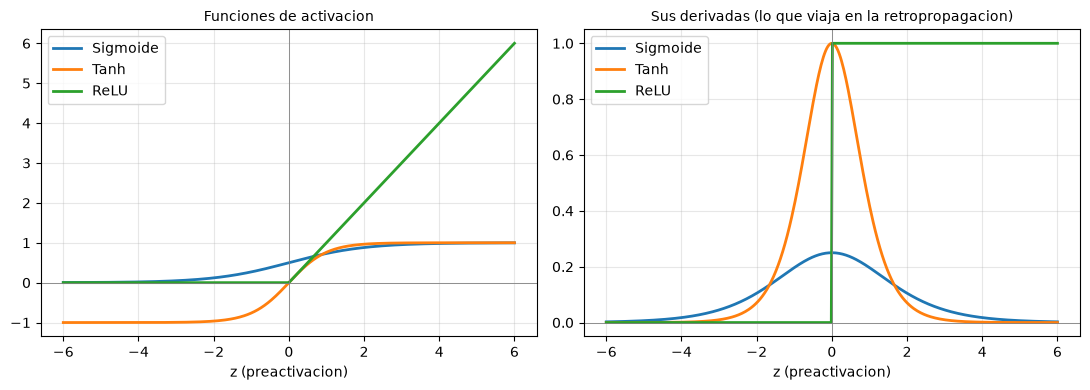

En el grafico de la derecha se ve el problema de la saturacion: las derivadas de sigmoide y tanh
caen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para
todo z > 0. Notese ademas que la derivada de la sigmoide no supera 0.25.


In [24]:
z = np.linspace(-6, 6, 400)

activaciones = {
    "Sigmoide": (1 / (1 + np.exp(-z)), lambda s: s * (1 - s)),
    "Tanh": (np.tanh(z), lambda s: 1 - s ** 2),
    "ReLU": (np.maximum(0, z), lambda s: (z > 0).astype(float)),
}

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

for nombre, (valores, derivada) in activaciones.items():
    ejes[0].plot(z, valores, label=nombre, linewidth=2)
    ejes[1].plot(z, derivada(valores), label=nombre, linewidth=2)

ejes[0].set_title("Funciones de activacion", fontsize=10)
ejes[1].set_title("Sus derivadas (lo que viaja en la retropropagacion)", fontsize=10)

for eje in ejes:
    eje.axhline(0, color="gray", linewidth=0.6)
    eje.axvline(0, color="gray", linewidth=0.6)
    eje.set_xlabel("z (preactivacion)")
    eje.grid(alpha=0.3)
    eje.legend()

plt.tight_layout()
plt.show()

print(
    "En el grafico de la derecha se ve el problema de la saturacion: las derivadas de sigmoide y tanh"
    "\ncaen a cero en los extremos (el gradiente se desvanece), mientras que la de ReLU vale 1 para"
    "\ntodo z > 0. Notese ademas que la derivada de la sigmoide no supera 0.25."
)


### Función de pérdida, backpropagation y optimizador

_La entropía cruzada categórica como medida del error, la retropropagación del gradiente y la actualización de los pesos mediante descenso del gradiente / Adam._

El forward pass produce una prediccion, pero por si solo no ensena nada. El aprendizaje necesita tres
piezas mas: una forma de **medir** el error, una forma de **repartir la culpa** de ese error entre los
parametros, y una **regla** para corregirlos.

**1. Funcion de perdida: entropia cruzada categorica**

Mide la distancia entre la distribucion predicha por softmax y el vector one-hot real. Como el one-hot
tiene un 1 en la clase correcta y 0 en el resto, la suma se reduce a un unico termino:

$$L = -\sum_{i=1}^{25} y_i \log(\hat{y}_i) = -\log(\hat{y}_{\text{clase correcta}})$$

Es decir: la perdida de un ejemplo depende **solo de la probabilidad que la red asigno a la clase
verdadera**. Si le dio 0,99, la perdida es casi 0; si le dio 0,01, la perdida se dispara. Ese crecimiento
logaritmico penaliza con dureza los errores cometidos con mucha confianza, que es el comportamiento
deseable. La perdida del batch es el promedio de las perdidas individuales -- y es ahi donde `class_weight`
interviene, ponderando cada termino segun la frecuencia de su clase.

Por que no usar accuracy como funcion a minimizar: el accuracy es escalonado, su gradiente es cero en casi
todas partes y no distingue entre acertar con 0,51 o con 0,99. Sirve para interpretar resultados, no para
optimizar. Por eso se monitorean ambos: se **optimiza** la perdida y se **lee** el accuracy.

**2. Backpropagation: de donde viene el error**

Conocida la perdida, hace falta saber cuanto contribuyo cada uno de los parametros. Eso es la derivada
parcial $\partial L / \partial w$, y calcularla directamente para cientos de miles de pesos seria
inviable. La retropropagacion lo resuelve aplicando la **regla de la cadena** en sentido inverso: parte
del error en la salida y lo propaga hacia atras capa por capa, reutilizando en cada paso lo ya calculado
en la capa posterior. Esto es lo que hace posible entrenar redes grandes, y tambien la razon de que la
derivada de la activacion importe tanto: aparece como factor multiplicativo en cada capa que se atraviesa
(de ahi el desvanecimiento del gradiente con sigmoide y la ventaja de ReLU).

El resultado es el **gradiente**: un vector que indica, para cada parametro, en que direccion habria que
moverlo para que la perdida aumente. Se avanza en la direccion contraria.

**3. Optimizador: como se corrigen los pesos**

La regla basica es el **descenso del gradiente**:

$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

donde $\eta$ es la **tasa de aprendizaje** (learning rate), el tamano del paso. Demasiado grande y el
entrenamiento oscila o diverge; demasiado pequeno y avanza con una lentitud inutil. En la practica no se
calcula el gradiente sobre todo el dataset (caro) ni sobre un solo ejemplo (ruidoso), sino sobre **batches**
de unas decenas o centenas de imagenes: es el descenso del gradiente por mini-lotes. Una **epoca** es una
pasada completa por el conjunto de entrenamiento, es decir, muchas actualizaciones de pesos.

**Eleccion: Adam.** Mejora el descenso del gradiente clasico en dos aspectos: acumula un **momento** de los
gradientes anteriores, lo que suaviza las oscilaciones, y adapta el tamano del paso **para cada parametro**
segun la magnitud tipica de su gradiente. En la practica converge mas rapido y es mucho menos sensible a
la eleccion inicial del learning rate, razon por la que se usa como punto de partida en la mayoria de los
trabajos. Se parte de su valor por defecto, 0,001, y su efecto se contrasta en la experimentacion.

**El ciclo completo de entrenamiento**

Para cada batch, y repitiendolo epoca tras epoca:

`forward pass` -> `calcular la perdida` -> `backpropagation` -> `el optimizador actualiza los pesos`


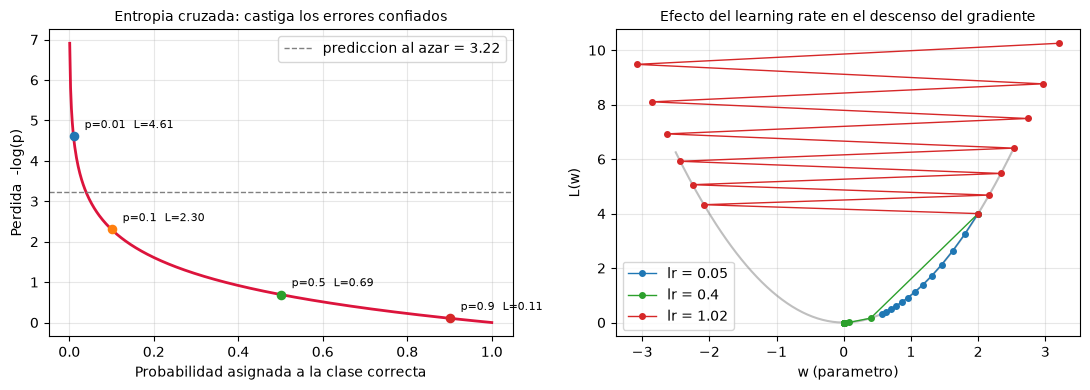

Perdida esperada de un modelo sin entrenar (1/25 a cada clase): 3.219
Es el valor de referencia con el que deberia arrancar el entrenamiento en la primera epoca.

En el grafico de la derecha: un lr pequeno (azul) converge pero lento, uno adecuado (verde)
llega rapido al minimo, y uno demasiado grande (rojo) se aleja y diverge.


In [25]:
# Perdida de un ejemplo segun la probabilidad asignada a la clase correcta
probabilidades = np.linspace(0.001, 1.0, 500)
perdidas = -np.log(probabilidades)

figura, ejes = plt.subplots(1, 2, figsize=(11, 4))

ejes[0].plot(probabilidades, perdidas, color="crimson", linewidth=2)
ejes[0].set_xlabel("Probabilidad asignada a la clase correcta")
ejes[0].set_ylabel("Perdida  -log(p)")
ejes[0].set_title("Entropia cruzada: castiga los errores confiados", fontsize=10)
ejes[0].grid(alpha=0.3)

for probabilidad in (0.01, 0.1, 0.5, 0.9):
    ejes[0].scatter([probabilidad], [-np.log(probabilidad)], zorder=3, s=35)
    ejes[0].annotate(
        f"p={probabilidad}  L={-np.log(probabilidad):.2f}",
        (probabilidad, -np.log(probabilidad)),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=8,
    )

# Referencias del problema: perdida esperada al predecir al azar entre 25 clases
perdida_azar = -np.log(1 / NUMERO_CLASES)
ejes[0].axhline(
    perdida_azar,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"prediccion al azar = {perdida_azar:.2f}",
)
ejes[0].legend()

# Efecto del learning rate sobre el descenso del gradiente en una parabola L(w) = w^2
ejes[1].plot(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200) ** 2, color="gray", alpha=0.5)

for tasa, color in ((0.05, "tab:blue"), (0.4, "tab:green"), (1.02, "tab:red")):
    w = 2.0
    trayectoria = [w]
    for _ in range(12):
        w = w - tasa * 2 * w  # derivada de w^2
        trayectoria.append(w)
    trayectoria = np.array(trayectoria)
    ejes[1].plot(
        trayectoria,
        trayectoria ** 2,
        "o-",
        color=color,
        markersize=4,
        linewidth=1,
        label=f"lr = {tasa}",
    )

ejes[1].set_xlabel("w (parametro)")
ejes[1].set_ylabel("L(w)")
ejes[1].set_title("Efecto del learning rate en el descenso del gradiente", fontsize=10)
ejes[1].grid(alpha=0.3)
ejes[1].legend()

plt.tight_layout()
plt.show()

print(f"Perdida esperada de un modelo sin entrenar (1/{NUMERO_CLASES} a cada clase): {perdida_azar:.3f}")
print("Es el valor de referencia con el que deberia arrancar el entrenamiento en la primera epoca.")
print(
    "\nEn el grafico de la derecha: un lr pequeno (azul) converge pero lento, uno adecuado (verde)"
    "\nllega rapido al minimo, y uno demasiado grande (rojo) se aleja y diverge."
)


## Modelo base: Perceptrón Multicapa (MLP)

_Implementación del modelo base con Keras, trasladando a código los componentes descritos en "Fundamentos: estructura de una red neuronal profunda"._

### Definición de la arquitectura

La arquitectura del modelo base traduce a código lo descrito en los fundamentos: una capa de entrada con
el vector aplanado, dos capas ocultas densas con ReLU y una capa de salida softmax con una neurona por
personaje. Entre medio se intercalan dos mecanismos de regularización:

- **Normalización por lotes (`BatchNormalization`).** Reescala las activaciones de cada capa para que
  mantengan una media y una varianza estables a lo largo del entrenamiento. Evita que la distribución que
  ve cada capa se desplace batch a batch, lo que permite usar una tasa de aprendizaje mayor y acelera la
  convergencia.
- **`Dropout`.** Durante el entrenamiento apaga al azar una fracción de las neuronas de la capa. Así
  ninguna neurona puede depender de la presencia de otra en particular y la red se ve obligada a
  distribuir la representación. Es la defensa principal contra el sobreajuste en una red densa con
  millones de parámetros y apenas unas 13 000 imágenes de entrenamiento.

La función `construir_mlp` deja como parámetros los tres factores que se modificarán en la
experimentación (número y ancho de las capas ocultas, activación y tasa de dropout), de modo que todas
las configuraciones comparadas se generen exactamente con el mismo código.

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fija las semillas de Python, NumPy y TensorFlow para que el entrenamiento sea reproducible
keras.utils.set_random_seed(SEMILLA)

NEURONAS_OCULTAS = (512, 256)
ACTIVACION = "relu"
TASA_DROPOUT = 0.3


def construir_mlp(
    neuronas_ocultas=NEURONAS_OCULTAS,
    activacion=ACTIVACION,
    tasa_dropout=TASA_DROPOUT,
    dimension_entrada=DIMENSION_ENTRADA,
    numero_clases=NUMERO_CLASES,
    nombre="mlp_base",
):
    """Construye un Perceptron Multicapa: entrada aplanada -> capas ocultas densas
    (activacion + BatchNorm + Dropout) -> salida softmax con una neurona por clase."""
    modelo = keras.Sequential(name=nombre)
    modelo.add(layers.Input(shape=(dimension_entrada,), name="entrada"))

    for posicion, neuronas in enumerate(neuronas_ocultas, start=1):
        modelo.add(layers.Dense(neuronas, activation=activacion, name=f"oculta_{posicion}"))
        modelo.add(layers.BatchNormalization(name=f"norm_{posicion}"))
        modelo.add(layers.Dropout(tasa_dropout, name=f"dropout_{posicion}"))

    modelo.add(layers.Dense(numero_clases, activation="softmax", name="salida"))
    return modelo


modelo_base = construir_mlp()

capas_texto = " -> ".join(str(n) for n in NEURONAS_OCULTAS)
print(f"TensorFlow {tf.__version__}")
print(f"Arquitectura: {DIMENSION_ENTRADA} -> {capas_texto} -> {NUMERO_CLASES}")
print(f"Activacion oculta: {ACTIVACION}   |   Dropout: {TASA_DROPOUT}   |   Salida: softmax")

TensorFlow 2.21.0
Arquitectura: 12288 -> 512 -> 256 -> 25
Activacion oculta: relu   |   Dropout: 0.3   |   Salida: softmax


### Justificación técnica de la arquitectura y de los hiperparámetros iniciales

Cada decisión del modelo base responde al problema concreto ya descrito: 12 288 entradas, 25 clases
fuertemente desbalanceadas y unas 13 000 imágenes de entrenamiento.

| Hiperparámetro | Valor elegido | Justificación |
|---|---|---|
| **Capas ocultas** | 2 | Con una sola capa la red es prácticamente un clasificador lineal sobre píxeles; con muchas más, en un dataset de este tamaño el sobreajuste y el costo crecen más rápido que la ganancia. Dos capas permiten componer dos niveles de abstracción y son el punto de partida habitual para un MLP sobre imágenes pequeñas |
| **Neuronas por capa** | 512 y 256 | Un embudo decreciente: la primera capa concentra ≈ 6,3 millones de parámetros y actúa como compresión del vector de 12 288 valores; la segunda refina esa representación antes de la salida. Reducir progresivamente obliga a la red a resumir en lugar de copiar la entrada |
| **Activación oculta** | ReLU | No se satura, su derivada vale 1 para z > 0 y es la más barata de calcular (ver "Funciones de activación"). Con sigmoide o tanh, dos capas ya bastan para que el gradiente empiece a atenuarse |
| **Activación de salida** | Softmax (25 neuronas) | Convierte las puntuaciones en una distribución de probabilidad que suma 1, que es la forma correcta para una clasificación multiclase de etiqueta única |
| **Dropout** | 0,3 | Valor intermedio: con millones de parámetros para 13 000 imágenes el riesgo de memorización es alto, pero una tasa de 0,5 sobre un MLP que además ya pierde la estructura espacial retrasa demasiado la convergencia |
| **BatchNormalization** | Tras cada capa oculta | Estabiliza la escala de las activaciones y permite un learning rate mayor sin que el entrenamiento se vuelva inestable |
| **Optimizador** | Adam | Adapta el paso por parámetro combinando momento y escalado según la magnitud histórica del gradiente. Con entradas muy dispares (píxeles de fondo casi constantes junto a zonas de alto contraste) converge bastante más rápido que el SGD puro |
| **Tasa de aprendizaje** | 0,001 | Valor por defecto de Adam y punto de partida estándar; se contrasta explícitamente en la experimentación |
| **Función de pérdida** | Categorical crossentropy | Corresponde a etiquetas one-hot con salida softmax |
| **Tamaño de batch** | 128 | Compromiso entre el ruido del gradiente (batches pequeños) y la estabilidad y el aprovechamiento de memoria (batches grandes) |
| **`class_weight`** | Pesos balanceados | Compensa la razón de desbalance ≈ 22:1 descrita en "Tratamiento del desbalance de clases" |

### Compilación del modelo

In [27]:
TASA_APRENDIZAJE = 1e-3


def compilar(modelo, tasa_aprendizaje=TASA_APRENDIZAJE):
    """Asocia al modelo el optimizador, la funcion de perdida y las metricas a monitorear."""
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=tasa_aprendizaje),
        loss="categorical_crossentropy",
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3"),
        ],
    )
    return modelo


compilar(modelo_base)

configuracion_base = pd.DataFrame(
    [
        ("Optimizador", "Adam"),
        ("Tasa de aprendizaje", TASA_APRENDIZAJE),
        ("Funcion de perdida", "categorical_crossentropy"),
        ("Metricas", "accuracy, top_3"),
        ("Neuronas ocultas", str(NEURONAS_OCULTAS)),
        ("Activacion oculta", ACTIVACION),
        ("Dropout", TASA_DROPOUT),
        ("Neuronas de salida", NUMERO_CLASES),
    ],
    columns=["Elemento", "Valor"],
)

display(configuracion_base)

,Elemento,Valor
0,Optimizador,Adam
1,Tasa de aprendizaje,0.001
2,Funcion de perdida,categorical_crossentropy
3,Metricas,"accuracy, top_3"
4,Neuronas ocultas,"(512, 256)"
5,Activacion oculta,relu
6,Dropout,0.3
7,Neuronas de salida,25


### Resumen del modelo

In [28]:
modelo_base.summary()

# Reparto de los parametros entre las capas
detalle_capas = pd.DataFrame(
    [
        (
            capa.name,
            capa.__class__.__name__,
            str(capa.output.shape),
            int(sum(np.prod(peso.shape) for peso in capa.trainable_weights)),
        )
        for capa in modelo_base.layers
    ],
    columns=["capa", "tipo", "forma_salida", "parametros"],
)
detalle_capas["% del total"] = (
    detalle_capas["parametros"] / max(detalle_capas["parametros"].sum(), 1) * 100
).round(1)

display(detalle_capas)

total_parametros = int(detalle_capas["parametros"].sum())
print(f"Parametros entrenables: {total_parametros:,}")
print(f"Imagenes de entrenamiento: {len(X_train):,}")
print(f"Razon parametros / ejemplos: {total_parametros / len(X_train):.0f} a 1")
print(
    "\nLa primera capa oculta concentra la mayor parte de los parametros porque es la unica"
    f"\nconectada a los {DIMENSION_ENTRADA} valores del vector de entrada. Esa razon de"
    "\nparametros por ejemplo es la que justifica el Dropout y la parada temprana."
)

Model: "mlp_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_1 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_2 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,432,793 (24.54 MB)

 Trainable params: 6,431,257 (24.53 MB)

 Non-trainable params: 1,536 (6.00 KB)

,capa,tipo,forma_salida,parametros,% del total
0,oculta_1,Dense,"(None, 512)",6291968,97.8
1,norm_1,BatchNormalization,"(None, 512)",1024,0.0
2,dropout_1,Dropout,"(None, 512)",0,0.0
3,oculta_2,Dense,"(None, 256)",131328,2.0
4,norm_2,BatchNormalization,"(None, 256)",512,0.0
5,dropout_2,Dropout,"(None, 256)",0,0.0
6,salida,Dense,"(None, 25)",6425,0.1


Parametros entrenables: 6,431,257
Imagenes de entrenamiento: 12,909
Razon parametros / ejemplos: 498 a 1

La primera capa oculta concentra la mayor parte de los parametros porque es la unica
conectada a los 12288 valores del vector de entrada. Esa razon de
parametros por ejemplo es la que justifica el Dropout y la parada temprana.


## Entrenamiento del modelo

_Ejecución del entrenamiento del modelo base y registro del historial._

### Configuración del entrenamiento

El entrenamiento se controla con tres decisiones y tres *callbacks*:

- **Épocas.** Se fija un máximo alto (60) y se deja que la parada temprana decida el número real. Fijar
  un número bajo a mano corre el riesgo de cortar antes de converger; uno alto sin control lleva a
  sobreajustar.
- **Batch de 128.** Cada actualización de pesos promedia el gradiente de 128 imágenes.
- **`class_weight`.** Los pesos calculados en el pre-procesamiento entran aquí: ponderan la pérdida de
  cada ejemplo según lo escasa que sea su clase.

| Callback | Qué hace | Por qué |
|---|---|---|
| `EarlyStopping` | Detiene el entrenamiento si `val_loss` no mejora en 8 épocas y restaura los pesos de la mejor época | Evita seguir entrenando cuando el modelo ya solo memoriza; `restore_best_weights` garantiza quedarse con la mejor versión, no con la última |
| `ReduceLROnPlateau` | Divide el learning rate a la mitad si `val_loss` se estanca 4 épocas | Permite pasos grandes al principio y ajustes finos al final, cerca del mínimo |
| `ModelCheckpoint` | Guarda en `models/` la mejor época según `val_loss` | Deja el modelo persistido en disco, reutilizable sin reentrenar |

La métrica que gobierna las decisiones es `val_loss` y no `val_accuracy`: con clases desbalanceadas la
accuracy de validación puede mantenerse plana mientras la pérdida ya empeora.

In [29]:
from pathlib import Path

EPOCAS_MAXIMAS = 60
TAMANO_BATCH = 128
DIRECTORIO_MODELOS = Path("../models")
DIRECTORIO_MODELOS.mkdir(parents=True, exist_ok=True)


def construir_callbacks(ruta_modelo, paciencia=8):
    """Parada temprana, reduccion del learning rate y guardado de la mejor epoca."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=paciencia,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(ruta_modelo),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


historial_base = modelo_base.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCAS_MAXIMAS,
    batch_size=TAMANO_BATCH,
    class_weight=pesos_por_clase,
    callbacks=construir_callbacks(DIRECTORIO_MODELOS / "mlp_base.keras"),
    verbose=2,
)

epocas_ejecutadas = len(historial_base.history["loss"])
mejor_epoca = int(np.argmin(historial_base.history["val_loss"])) + 1
print(f"\nEpocas ejecutadas: {epocas_ejecutadas} de {EPOCAS_MAXIMAS} (parada temprana)")
print(f"Mejor epoca segun val_loss: {mejor_epoca}")

Epoch 1/60


101/101 - 6s - 60ms/step - accuracy: 0.1497 - loss: 3.2081 - top_3: 0.3263 - val_accuracy: 0.2007 - val_loss: 2.9337 - val_top_3: 0.4049 - learning_rate: 0.0010


Epoch 2/60


101/101 - 4s - 41ms/step - accuracy: 0.2405 - loss: 2.6350 - top_3: 0.4531 - val_accuracy: 0.2134 - val_loss: 2.8649 - val_top_3: 0.4164 - learning_rate: 0.0010


Epoch 3/60


...


Epoch 46: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


101/101 - 4s - 35ms/step - accuracy: 0.6073 - loss: 0.8939 - top_3: 0.8187 - val_accuracy: 0.4839 - val_loss: 1.8950 - val_top_3: 0.6936 - learning_rate: 3.1250e-05


Epoch 46: early stopping


Restoring model weights from the end of the best epoch: 38.



Epocas ejecutadas: 46 de 60 (parada temprana)
Mejor epoca segun val_loss: 38


### Curvas de aprendizaje del modelo base

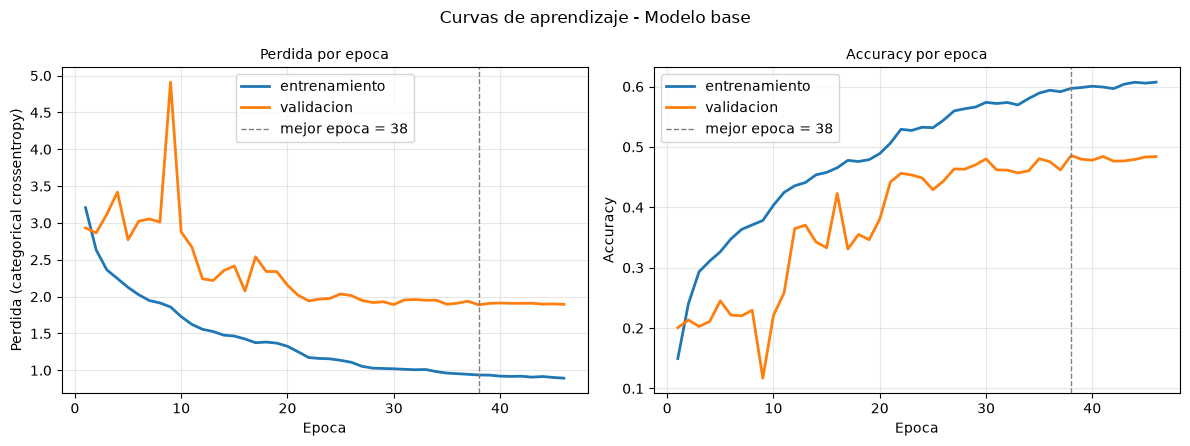

In [30]:
def graficar_curvas(historial, titulo="Modelo base"):
    """Dibuja perdida y accuracy de entrenamiento y validacion por epoca."""
    registro = historial.history if hasattr(historial, "history") else historial
    epocas = range(1, len(registro["loss"]) + 1)
    epoca_optima = int(np.argmin(registro["val_loss"])) + 1

    figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

    ejes[0].plot(epocas, registro["loss"], label="entrenamiento", linewidth=2)
    ejes[0].plot(epocas, registro["val_loss"], label="validacion", linewidth=2)
    ejes[0].set_ylabel("Perdida (categorical crossentropy)")
    ejes[0].set_title("Perdida por epoca", fontsize=10)

    ejes[1].plot(epocas, registro["accuracy"], label="entrenamiento", linewidth=2)
    ejes[1].plot(epocas, registro["val_accuracy"], label="validacion", linewidth=2)
    ejes[1].set_ylabel("Accuracy")
    ejes[1].set_title("Accuracy por epoca", fontsize=10)

    for eje in ejes:
        eje.axvline(
            epoca_optima,
            color="gray",
            linestyle="--",
            linewidth=1,
            label=f"mejor epoca = {epoca_optima}",
        )
        eje.set_xlabel("Epoca")
        eje.grid(alpha=0.3)
        eje.legend()

    figura.suptitle(f"Curvas de aprendizaje - {titulo}")
    plt.tight_layout()
    plt.show()


graficar_curvas(historial_base)

### Interpretación de las curvas

In [31]:
from sklearn.metrics import f1_score

registro = historial_base.history
indice_optimo = int(np.argmin(registro["val_loss"]))

# F1 macro en validacion con los pesos restaurados de la mejor epoca
probabilidades_val = modelo_base.predict(X_val, batch_size=256, verbose=0)
predicciones_val = probabilidades_val.argmax(axis=1)
f1_macro_val = f1_score(y_val_idx, predicciones_val, average="macro")

diagnostico = pd.DataFrame(
    [
        ("Epocas ejecutadas", len(registro["loss"])),
        ("Mejor epoca (val_loss)", indice_optimo + 1),
        ("Perdida entrenamiento", round(registro["loss"][indice_optimo], 4)),
        ("Perdida validacion", round(registro["val_loss"][indice_optimo], 4)),
        ("Accuracy entrenamiento", round(registro["accuracy"][indice_optimo], 4)),
        ("Accuracy validacion", round(registro["val_accuracy"][indice_optimo], 4)),
        ("Top-3 accuracy validacion", round(registro["val_top_3"][indice_optimo], 4)),
        ("F1 macro validacion", round(float(f1_macro_val), 4)),
        (
            "Brecha train - val (accuracy)",
            round(registro["accuracy"][indice_optimo] - registro["val_accuracy"][indice_optimo], 4),
        ),
    ],
    columns=["Indicador", "Valor"],
)

display(diagnostico)

brecha = registro["accuracy"][indice_optimo] - registro["val_accuracy"][indice_optimo]
if brecha > 0.15:
    lectura = "sobreajuste claro: la red memoriza el entrenamiento y generaliza bastante peor"
elif brecha > 0.05:
    lectura = "sobreajuste moderado, contenido por el Dropout y la parada temprana"
else:
    lectura = "sin sobreajuste apreciable; las dos curvas evolucionan juntas"

print(f"Brecha train - val en accuracy: {brecha:.3f} -> {lectura}.")
print(
    f"Accuracy de validacion ({registro['val_accuracy'][indice_optimo]:.3f}) frente a los baselines:"
    f" azar 0.040 y clase mayoritaria 0.114."
)

,Indicador,Valor
0,Epocas ejecutadas,46.0000
1,Mejor epoca (val_loss),38.0000
2,Perdida entrenamiento,0.9365
3,Perdida validacion,1.8884
4,Accuracy entrenamiento,0.5969
5,Accuracy validacion,0.4857
6,Top-3 accuracy validacion,0.6918
7,F1 macro validacion,0.4566
8,Brecha train - val (accuracy),0.1111


Brecha train - val en accuracy: 0.111 -> sobreajuste moderado, contenido por el Dropout y la parada temprana.
Accuracy de validacion (0.486) frente a los baselines: azar 0.040 y clase mayoritaria 0.114.


**Cómo se leen estas curvas**

Hay tres cosas que mirar en los gráficos anteriores:

1. **La separación entre las dos curvas de pérdida.** Mientras ambas bajan juntas, la red está
   aprendiendo estructura real del problema. En cuanto la pérdida de validación se aplana o sube
   mientras la de entrenamiento sigue bajando, lo que la red gana ya es memorización de las imágenes
   concretas del conjunto de entrenamiento: ese punto de cruce es el sobreajuste y es justo lo que
   detecta `EarlyStopping`.
2. **La época en que la validación deja de mejorar** (línea vertical punteada). Es la que se conserva,
   porque `restore_best_weights=True` devuelve los pesos de ese momento, y no los del final.
3. **El efecto de la regularización.** El Dropout hace que la curva de entrenamiento vaya *por debajo* de
   su potencial —parte de la red está apagada en cada paso— y por eso la brecha entre train y validación
   es menor de la que tendría el mismo MLP sin regularizar. El escalón que a veces se ve en las curvas
   corresponde a `ReduceLROnPlateau` bajando el learning rate.

La tabla de arriba resume el diagnóstico: la brecha entre entrenamiento y validación cuantifica el
sobreajuste, y la distancia frente a los baselines (4,0 % al azar, 11,4 % prediciendo siempre la clase
mayoritaria) confirma que el modelo efectivamente aprendió algo del problema.

## Experimentación: comparación de configuraciones

_Metodología de experimentación básica: partiendo del modelo base se modifica **un factor a la vez** y se compara su efecto sobre la métrica de validación, manteniendo fija la semilla y el resto de los hiperparámetros._

### Diseño de los experimentos

La comparación sigue el principio de **un factor a la vez**: cada experimento cambia exactamente un
hiperparámetro respecto del modelo base y deja el resto idéntico —misma semilla, misma partición, mismos
pesos por clase, mismos callbacks—. Así, cualquier diferencia en la métrica de validación es atribuible
al factor modificado y no a la interacción de varios cambios simultáneos.

| Exp. | Factor que cambia | Configuración | Qué pone a prueba |
|---|---|---|---|
| **Base** | — | 2 capas (512, 256), ReLU, lr 0,001, batch 128 | Referencia |
| **E1** | Profundidad | 1 capa oculta (512) | Si una sola capa basta, o si la segunda aporta |
| **E2** | Profundidad y ancho | 3 capas (1024, 512, 256) | Si más capacidad mejora o solo sobreajusta |
| **E3** | Activación | 2 capas (512, 256) con tanh | El costo de una activación que se satura |
| **E4** | Tasa de aprendizaje | lr 0,0001 | Convergencia lenta pero estable frente al valor por defecto |
| **E5** | Tamaño de batch | batch 512 | Menos ruido por actualización y menos actualizaciones por época |

Las métricas registradas para cada configuración son la **accuracy** de validación —comparable con los
baselines— y el **F1 macro** de validación, que promedia sin ponderar las 25 clases y es la métrica que
realmente refleja si el modelo atiende a los personajes minoritarios. La selección final se hace por F1
macro, por el desbalance ya documentado.

Para acotar el costo, los experimentos usan un máximo de 35 épocas y una paciencia de 6 (el modelo base
se entrenó con 60 y paciencia 8); todos comparten exactamente ese presupuesto entre sí.

In [32]:
import time

EPOCAS_EXPERIMENTO = 35
PACIENCIA_EXPERIMENTO = 6

# Cada entrada cambia UN solo factor respecto del modelo base
experimentos = [
    {"nombre": "E1 - 1 capa (512)", "neuronas": (512,)},
    {"nombre": "E2 - 3 capas (1024,512,256)", "neuronas": (1024, 512, 256)},
    {"nombre": "E3 - activacion tanh", "activacion": "tanh"},
    {"nombre": "E4 - learning rate 1e-4", "tasa_aprendizaje": 1e-4},
    {"nombre": "E5 - batch 512", "batch": 512},
]


def entrenar_configuracion(
    nombre,
    neuronas=NEURONAS_OCULTAS,
    activacion=ACTIVACION,
    tasa_dropout=TASA_DROPOUT,
    tasa_aprendizaje=TASA_APRENDIZAJE,
    batch=TAMANO_BATCH,
    epocas=EPOCAS_EXPERIMENTO,
    paciencia=PACIENCIA_EXPERIMENTO,
):
    """Entrena una configuracion y devuelve el modelo, su historial y sus metricas de validacion."""
    keras.utils.set_random_seed(SEMILLA)  # misma inicializacion para todas las configuraciones

    identificador = nombre.split(" - ")[0].strip().lower().replace(" ", "_")
    modelo = construir_mlp(
        neuronas_ocultas=neuronas,
        activacion=activacion,
        tasa_dropout=tasa_dropout,
        nombre=f"mlp_{identificador}",
    )
    compilar(modelo, tasa_aprendizaje=tasa_aprendizaje)

    inicio = time.time()
    historial = modelo.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epocas,
        batch_size=batch,
        class_weight=pesos_por_clase,
        callbacks=construir_callbacks(
            DIRECTORIO_MODELOS / f"mlp_{identificador}.keras", paciencia=paciencia
        ),
        verbose=0,
    )
    duracion = time.time() - inicio

    indice = int(np.argmin(historial.history["val_loss"]))
    predicciones = modelo.predict(X_val, batch_size=256, verbose=0).argmax(axis=1)

    resultado = {
        "experimento": nombre,
        "capas_ocultas": len(neuronas),
        "neuronas": " - ".join(str(n) for n in neuronas),
        "activacion": activacion,
        "dropout": tasa_dropout,
        "learning_rate": tasa_aprendizaje,
        "batch": batch,
        "epocas": len(historial.history["loss"]),
        "mejor_epoca": indice + 1,
        "parametros": int(modelo.count_params()),
        "val_loss": round(historial.history["val_loss"][indice], 4),
        "val_accuracy": round(historial.history["val_accuracy"][indice], 4),
        "val_f1_macro": round(float(f1_score(y_val_idx, predicciones, average="macro")), 4),
        "segundos": round(duracion, 1),
    }
    return modelo, historial, resultado


modelos = {}
historiales = {}
resultados = []

# El modelo base ya esta entrenado: se incorpora a la comparacion sin volver a entrenarlo
resultados.append(
    {
        "experimento": "Base - 2 capas (512,256)",
        "capas_ocultas": len(NEURONAS_OCULTAS),
        "neuronas": " - ".join(str(n) for n in NEURONAS_OCULTAS),
        "activacion": ACTIVACION,
        "dropout": TASA_DROPOUT,
        "learning_rate": TASA_APRENDIZAJE,
        "batch": TAMANO_BATCH,
        "epocas": len(historial_base.history["loss"]),
        "mejor_epoca": indice_optimo + 1,
        "parametros": int(modelo_base.count_params()),
        "val_loss": round(registro["val_loss"][indice_optimo], 4),
        "val_accuracy": round(registro["val_accuracy"][indice_optimo], 4),
        "val_f1_macro": round(float(f1_macro_val), 4),
        "segundos": np.nan,
    }
)
modelos["Base - 2 capas (512,256)"] = modelo_base
historiales["Base - 2 capas (512,256)"] = historial_base.history

for configuracion in experimentos:
    nombre = configuracion.pop("nombre")
    print(f"Entrenando {nombre} ...")
    modelo, historial, resultado = entrenar_configuracion(nombre, **configuracion)
    modelos[nombre] = modelo
    historiales[nombre] = historial.history
    resultados.append(resultado)
    print(
        f"   val_accuracy={resultado['val_accuracy']:.4f}"
        f"   val_f1_macro={resultado['val_f1_macro']:.4f}"
        f"   epocas={resultado['epocas']}   {resultado['segundos']:.0f} s"
    )

tabla_experimentos = pd.DataFrame(resultados)
display(tabla_experimentos)

Entrenando E1 - 1 capa (512) ...



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 1.


   val_accuracy=0.2723   val_f1_macro=0.2298   epocas=7   26 s
Entrenando E2 - 3 capas (1024,512,256) ...


...


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 12.


   val_accuracy=0.2952   val_f1_macro=0.2622   epocas=18   31 s


,experimento,capas_ocultas,neuronas,activacion,dropout,learning_rate,batch,epocas,mejor_epoca,parametros,val_loss,val_accuracy,val_f1_macro,segundos
0,"Base - 2 capas (512,256)",2,512 - 256,relu,0.3,0.0010,128,46,38,6432793,1.8884,0.4857,0.4566,NaN
1,E1 - 1 capa (512),1,512,relu,0.3,0.0010,128,7,1,6306841,2.6952,0.2723,0.2298,26.0
2,"E2 - 3 capas (1024,512,256)",3,1024 - 512 - 256,relu,0.3,0.0010,128,35,34,13253657,1.7795,0.5050,0.4845,271.5
3,E3 - activacion tanh,2,512 - 256,tanh,0.3,0.0010,128,7,1,6432793,3.7562,0.0740,0.0202,26.7
4,E4 - learning rate 1e-4,2,512 - 256,relu,0.3,0.0001,128,35,33,6432793,2.0667,0.4501,0.4142,129.2
5,E5 - batch 512,2,512 - 256,relu,0.3,0.0010,512,18,12,6432793,2.5106,0.2952,0.2622,31.3


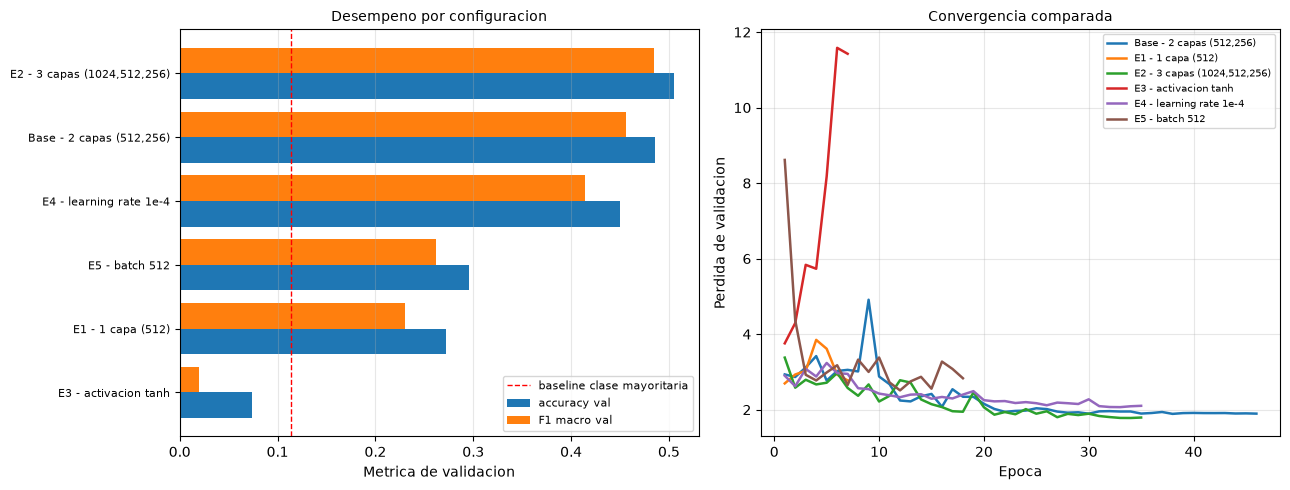

In [33]:
# Comparacion visual de las configuraciones por accuracy y F1 macro de validacion
orden_resultados = tabla_experimentos.sort_values("val_f1_macro", ascending=True)
posiciones = np.arange(len(orden_resultados))

figura, ejes = plt.subplots(1, 2, figsize=(13, 5))

ejes[0].barh(posiciones - 0.2, orden_resultados["val_accuracy"], height=0.4, label="accuracy val")
ejes[0].barh(posiciones + 0.2, orden_resultados["val_f1_macro"], height=0.4, label="F1 macro val")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(orden_resultados["experimento"], fontsize=8)
ejes[0].axvline(0.114, color="red", linestyle="--", linewidth=1, label="baseline clase mayoritaria")
ejes[0].set_xlabel("Metrica de validacion")
ejes[0].set_title("Desempeno por configuracion", fontsize=10)
ejes[0].legend(fontsize=8)
ejes[0].grid(alpha=0.3, axis="x")

for nombre, registro_historial in historiales.items():
    ejes[1].plot(
        range(1, len(registro_historial["val_loss"]) + 1),
        registro_historial["val_loss"],
        label=nombre,
        linewidth=1.8,
    )
ejes[1].set_xlabel("Epoca")
ejes[1].set_ylabel("Perdida de validacion")
ejes[1].set_title("Convergencia comparada", fontsize=10)
ejes[1].grid(alpha=0.3)
ejes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

### Efecto del número de capas ocultas y de neuronas

,experimento,capas_ocultas,neuronas,parametros,val_accuracy,val_f1_macro,epocas,segundos,parametros_millones
0,E1 - 1 capa (512),1,512,6306841,0.2723,0.2298,7,26.0,6.31
1,"Base - 2 capas (512,256)",2,512 - 256,6432793,0.4857,0.4566,46,NaN,6.43
2,"E2 - 3 capas (1024,512,256)",3,1024 - 512 - 256,13253657,0.5050,0.4845,35,271.5,13.25


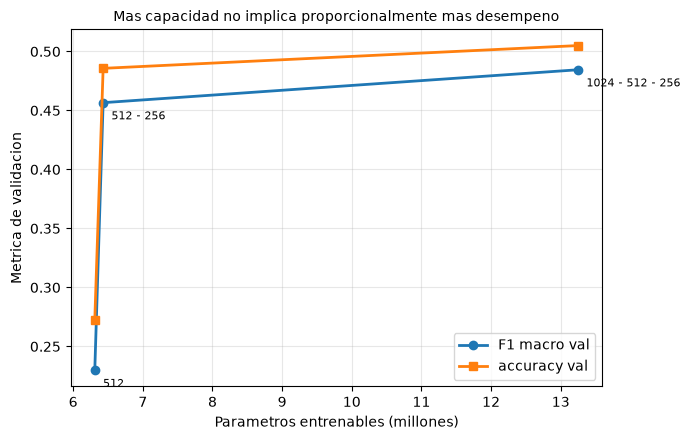

In [34]:
# Solo las configuraciones que cambian la arquitectura (misma activacion, lr y batch que el base)
comparacion_arquitectura = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E1|E2")
][["experimento", "capas_ocultas", "neuronas", "parametros", "val_accuracy", "val_f1_macro", "epocas", "segundos"]]
comparacion_arquitectura = comparacion_arquitectura.sort_values("parametros").reset_index(drop=True)

comparacion_arquitectura["parametros_millones"] = (
    comparacion_arquitectura["parametros"] / 1e6
).round(2)

display(comparacion_arquitectura)

figura, eje = plt.subplots(figsize=(7, 4.5))
eje.plot(
    comparacion_arquitectura["parametros_millones"],
    comparacion_arquitectura["val_f1_macro"],
    marker="o",
    linewidth=2,
    label="F1 macro val",
)
eje.plot(
    comparacion_arquitectura["parametros_millones"],
    comparacion_arquitectura["val_accuracy"],
    marker="s",
    linewidth=2,
    label="accuracy val",
)
for _, fila in comparacion_arquitectura.iterrows():
    eje.annotate(
        fila["neuronas"],
        (fila["parametros_millones"], fila["val_f1_macro"]),
        textcoords="offset points",
        xytext=(6, -12),
        fontsize=8,
    )
eje.set_xlabel("Parametros entrenables (millones)")
eje.set_ylabel("Metrica de validacion")
eje.set_title("Mas capacidad no implica proporcionalmente mas desempeno", fontsize=10)
eje.grid(alpha=0.3)
eje.legend()
plt.tight_layout()
plt.show()

**Lectura.** La profundidad sí importa, pero con rendimientos decrecientes y a un costo creciente. Con
una sola capa oculta (E1) el modelo se queda muy atrás —F1 macro 0,230 frente a 0,457 del base—: sin una
segunda etapa de composición, la red no alcanza a separar 25 clases a partir de píxeles sueltos y la
parada temprana la corta a las 7 épocas. La tercera capa de E2 sí aporta, pero poco: +0,028 de F1 macro
sobre el modelo base a cambio de **duplicar** los parámetros (13,3 millones frente a 6,4) y de multiplicar
por más de cuatro el tiempo de entrenamiento.

Esa desproporción es la conclusión relevante: cada millón de parámetros adicionales se paga en memoria,
en tiempo y en riesgo de sobreajuste, mientras la ganancia se aplana. La razón es estructural y no se
resuelve con más capacidad: al aplanar la imagen, todas las capas densas trabajan sobre píxeles sueltos,
sin noción de vecindad. Añadir neuronas aumenta el número de combinaciones lineales de píxeles
disponibles, pero ninguna de ellas recupera la información espacial que se perdió en el aplanado, que es
el verdadero cuello de botella de este enfoque.

### Efecto de la función de activación

,experimento,activacion,val_loss,val_accuracy,val_f1_macro,epocas,mejor_epoca
0,"Base - 2 capas (512,256)",relu,1.8884,0.4857,0.4566,46,38
1,E3 - activacion tanh,tanh,3.7562,0.0740,0.0202,7,1


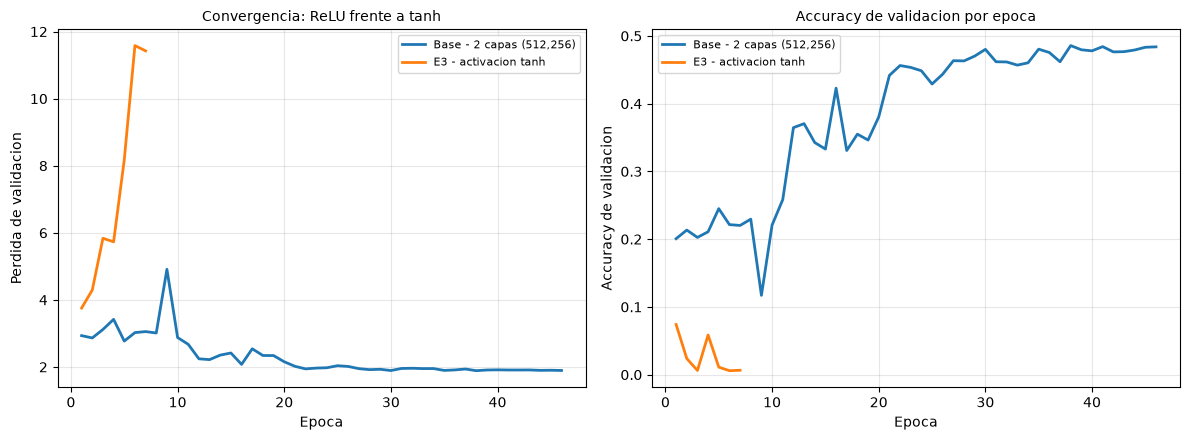

In [35]:
comparacion_activacion = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E3")
][["experimento", "activacion", "val_loss", "val_accuracy", "val_f1_macro", "epocas", "mejor_epoca"]]

display(comparacion_activacion.reset_index(drop=True))

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre in comparacion_activacion["experimento"]:
    registro_historial = historiales[nombre]
    epocas_rango = range(1, len(registro_historial["loss"]) + 1)
    ejes[0].plot(epocas_rango, registro_historial["val_loss"], linewidth=2, label=nombre)
    ejes[1].plot(epocas_rango, registro_historial["val_accuracy"], linewidth=2, label=nombre)

ejes[0].set_ylabel("Perdida de validacion")
ejes[0].set_title("Convergencia: ReLU frente a tanh", fontsize=10)
ejes[1].set_ylabel("Accuracy de validacion")
ejes[1].set_title("Accuracy de validacion por epoca", fontsize=10)

for eje in ejes:
    eje.set_xlabel("Epoca")
    eje.grid(alpha=0.3)
    eje.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lectura.** La diferencia es mucho más drástica de lo esperado: con tanh el entrenamiento directamente
no despega. El F1 macro de validación queda en 0,020 —por debajo incluso del baseline de la clase
mayoritaria— y `EarlyStopping` corta a las 7 épocas restaurando los pesos de la primera, señal de que la
pérdida de validación nunca mejoró.

La causa es la discutida en "Funciones de activación". La tanh está acotada en (-1, 1) y su derivada cae
a cero en los extremos: con 12 288 entradas, las preactivaciones de la primera capa son grandes y muchas
unidades entran saturadas desde el inicio, de modo que el gradiente que las atraviesa es prácticamente
nulo y esas neuronas nunca aprenden. ReLU no tiene ese techo —su derivada vale 1 para todo z > 0—,
produce activaciones dispersas y es más barata de calcular.

Conviene ser preciso sobre el alcance de esta comparación: no demuestra que tanh sea inutilizable, sino
que **con el resto de los hiperparámetros del modelo base** (lr 0,001, BatchNorm, 35 épocas) fracasa. Con
un learning rate mucho menor y más épocas probablemente aprendería algo, pero ese es justamente el punto:
ReLU funciona con la configuración por defecto y tanh exigiría reajustar todo lo demás.

### Efecto del número de épocas, el tamaño de batch y la tasa de aprendizaje

,experimento,learning_rate,batch,epocas,mejor_epoca,val_loss,val_accuracy,val_f1_macro,segundos
0,"Base - 2 capas (512,256)",0.0010,128,46,38,1.8884,0.4857,0.4566,NaN
1,E4 - learning rate 1e-4,0.0001,128,35,33,2.0667,0.4501,0.4142,129.2
2,E5 - batch 512,0.0010,512,18,12,2.5106,0.2952,0.2622,31.3


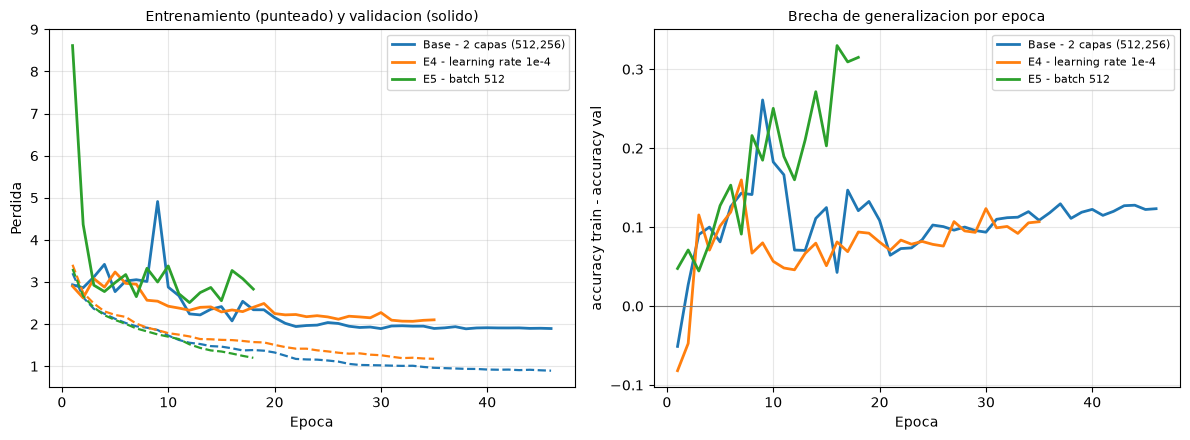

In [36]:
comparacion_optimizacion = tabla_experimentos[
    tabla_experimentos["experimento"].str.contains("Base|E4|E5")
][["experimento", "learning_rate", "batch", "epocas", "mejor_epoca", "val_loss", "val_accuracy", "val_f1_macro", "segundos"]]

display(comparacion_optimizacion.reset_index(drop=True))

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre in comparacion_optimizacion["experimento"]:
    registro_historial = historiales[nombre]
    epocas_rango = range(1, len(registro_historial["loss"]) + 1)
    ejes[0].plot(epocas_rango, registro_historial["loss"], linewidth=1.6, linestyle="--")
    ejes[0].plot(
        epocas_rango,
        registro_historial["val_loss"],
        linewidth=2,
        label=nombre,
        color=ejes[0].lines[-1].get_color(),
    )
    ejes[1].plot(
        epocas_rango,
        np.array(registro_historial["accuracy"]) - np.array(registro_historial["val_accuracy"]),
        linewidth=2,
        label=nombre,
    )

ejes[0].set_ylabel("Perdida")
ejes[0].set_title("Entrenamiento (punteado) y validacion (solido)", fontsize=10)
ejes[1].axhline(0, color="gray", linewidth=0.8)
ejes[1].set_ylabel("accuracy train - accuracy val")
ejes[1].set_title("Brecha de generalizacion por epoca", fontsize=10)

for eje in ejes:
    eje.set_xlabel("Epoca")
    eje.grid(alpha=0.3)
    eje.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Lectura.** Los tres hiperparámetros de optimización están acoplados y conviene leerlos juntos:

- **Tasa de aprendizaje.** Con 1e-4 (E4) cada paso es diez veces más corto: el descenso es más suave y
  estable, pero dentro del mismo presupuesto de épocas el modelo queda más lejos del mínimo —F1 macro
  0,414 frente a 0,457 del base—. Es el comportamiento esperado según la ilustración del descenso del
  gradiente de los fundamentos: un learning rate demasiado pequeño no diverge, simplemente no llega a
  tiempo.
- **Tamaño de batch.** Con batch 512 (E5) cada época contiene cuatro veces menos actualizaciones de
  pesos, y el efecto es grande: F1 macro 0,262, con parada temprana a las 18 épocas. El gradiente es
  menos ruidoso —las curvas se ven más lisas— pero se avanza mucho menos por época, y además ese ruido
  que se pierde tenía un efecto regularizador.
- **Número de épocas.** No es un valor elegido a mano: la columna `mejor_epoca` muestra dónde la
  validación tocó su mínimo en cada configuración, y `epocas` cuánto se entrenó antes de que
  `EarlyStopping` cortara; la distancia entre ambas es la paciencia consumida. El modelo base alcanzó su
  mínimo en la época 38 de 46, lo que confirma que necesitaba efectivamente ese presupuesto largo: las
  configuraciones que se detuvieron pronto no lo hicieron por haber convergido, sino por no estar
  mejorando.

El panel derecho muestra la brecha entre accuracy de entrenamiento y de validación época a época: cuando
esa curva crece de forma sostenida, cada época adicional se está invirtiendo en memorizar, no en
generalizar.

### Selección del modelo final

In [37]:
# El criterio de seleccion es el F1 macro de validacion, no la accuracy:
# promedia las 25 clases sin ponderar y penaliza ignorar a los personajes minoritarios
ranking = tabla_experimentos.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
display(ranking[["experimento", "val_accuracy", "val_f1_macro", "val_loss", "parametros", "epocas"]])

nombre_final = ranking.loc[0, "experimento"]
modelo_final = modelos[nombre_final]

print(f"Configuracion seleccionada: {nombre_final}")
print(f"  accuracy validacion : {ranking.loc[0, 'val_accuracy']:.4f}")
print(f"  F1 macro validacion : {ranking.loc[0, 'val_f1_macro']:.4f}")
print(f"  parametros          : {ranking.loc[0, 'parametros']:,}")
print(f"\nDiferencia en F1 macro frente a la segunda ({ranking.loc[1, 'experimento']}): "
      f"{ranking.loc[0, 'val_f1_macro'] - ranking.loc[1, 'val_f1_macro']:+.4f}")

ruta_modelo_final = DIRECTORIO_MODELOS / "mlp_final.keras"
modelo_final.save(ruta_modelo_final)
print(f"\nModelo final guardado en: {ruta_modelo_final}")

,experimento,val_accuracy,val_f1_macro,val_loss,parametros,epocas
0,"E2 - 3 capas (1024,512,256)",0.5050,0.4845,1.7795,13253657,35
1,"Base - 2 capas (512,256)",0.4857,0.4566,1.8884,6432793,46
2,E4 - learning rate 1e-4,0.4501,0.4142,2.0667,6432793,35
3,E5 - batch 512,0.2952,0.2622,2.5106,6432793,18
4,E1 - 1 capa (512),0.2723,0.2298,2.6952,6306841,7
5,E3 - activacion tanh,0.0740,0.0202,3.7562,6432793,7


Configuracion seleccionada: E2 - 3 capas (1024,512,256)
  accuracy validacion : 0.5050
  F1 macro validacion : 0.4845
  parametros          : 13,253,657

Diferencia en F1 macro frente a la segunda (Base - 2 capas (512,256)): +0.0279



Modelo final guardado en: ..\models\mlp_final.keras


**Justificación de la decisión.** La configuración elegida es la que maximiza el **F1 macro de
validación**, y no la que maximiza la accuracy. Con una razón de desbalance de 22:1, la accuracy premia
acertar en los personajes abundantes y apenas se resiente si el modelo ignora por completo a los
escasos; el F1 macro, al promediar las 25 clases sin ponderarlas, sí lo penaliza. Como el objetivo
declarado es reconocer personajes —los 25, no solo a Homero—, esa es la métrica coherente con el
problema.

Cuando dos configuraciones quedan prácticamente empatadas en F1 macro, el criterio de desempate es el
número de parámetros: a igual desempeño se prefiere la red más pequeña, por costo de entrenamiento y por
menor riesgo de sobreajuste.

El modelo seleccionado es el que se evalúa en la sección siguiente sobre el conjunto **test**, que hasta
este punto no se ha tocado ni para entrenar ni para elegir hiperparámetros.

## Evaluación y métricas de desempeño

_Evaluación del modelo final sobre el conjunto test, no utilizado durante el entrenamiento ni durante la experimentación._

El conjunto `test` se procesa ahora **con exactamente las mismas funciones** que el conjunto de
entrenamiento: el mismo índice de rutas, el mismo redimensionado a 64 x 64, la misma normalización por
255, el mismo aplanado y —esto es lo crítico— el mismo diccionario `clase_a_indice`. Si las clases se
volvieran a numerar a partir del test, el índice 3 podría corresponder a un personaje distinto del que
vio el modelo durante el entrenamiento y toda la evaluación quedaría invalidada.

In [38]:
# Carga y pre-procesamiento del conjunto test, reutilizando las mismas funciones
direccion_test = DATASET_BASE / "test"
datos_test = construir_indice(direccion_test)

# El mapeo de clases es el del entrenamiento: no se recalcula
clases_test = sorted(datos_test["personaje"].unique())
if clases_test != clases:
    raise ValueError("Las clases del conjunto test no coinciden con las del entrenamiento")

datos_test["etiqueta"] = datos_test["personaje"].map(clase_a_indice)

imagenes_test = np.stack([cargar_y_redimensionar(ruta) for ruta in datos_test["ruta"]])
X_test = (imagenes_test.astype(np.float32) / VALOR_MAXIMO_PIXEL).reshape(len(datos_test), -1)
y_test_idx = datos_test["etiqueta"].to_numpy()
y_test = np.eye(NUMERO_CLASES, dtype=np.float32)[y_test_idx]

comprobaciones_test = pd.DataFrame(
    [
        ("Mismas clases que train", len(clases_test), NUMERO_CLASES, clases_test == clases),
        ("Dimension de entrada", X_test.shape[1], DIMENSION_ENTRADA, X_test.shape[1] == DIMENSION_ENTRADA),
        ("Tipo de dato", str(X_test.dtype), "float32", X_test.dtype == np.float32),
        (
            "Rango [0, 1]",
            f"[{X_test.min():.3f}, {X_test.max():.3f}]",
            "[0.0, 1.0]",
            bool(X_test.min() >= 0.0 and X_test.max() <= 1.0),
        ),
        ("Etiquetas alineadas", len(y_test_idx), X_test.shape[0], len(y_test_idx) == X_test.shape[0]),
    ],
    columns=["Comprobacion", "Obtenido", "Esperado", "Correcto"],
)

display(comprobaciones_test)
print(f"X_test: {X_test.shape}   y_test: {y_test.shape}")

,Comprobacion,Obtenido,Esperado,Correcto
0,Mismas clases que train,25,25,True
1,Dimension de entrada,12288,12288,True
2,Tipo de dato,float32,float32,True
3,"Rango [0, 1]","[0.000, 1.000]","[0.0, 1.0]",True
4,Etiquetas alineadas,3937,3937,True


X_test: (3937, 12288)   y_test: (3937, 25)


### Accuracy global sobre el conjunto de prueba

In [39]:
perdida_test, accuracy_test, top3_test = modelo_final.evaluate(
    X_test, y_test, batch_size=256, verbose=0
)

probabilidades_test = modelo_final.predict(X_test, batch_size=256, verbose=0)
predicciones_test = probabilidades_test.argmax(axis=1)
confianza_test = probabilidades_test.max(axis=1)

# Baselines definidos en "Definicion del problema de clasificacion"
conteos_test = np.bincount(y_test_idx, minlength=NUMERO_CLASES)
baseline_azar = 1 / NUMERO_CLASES
baseline_mayoritaria = conteos_test.max() / conteos_test.sum()
f1_macro_test = f1_score(y_test_idx, predicciones_test, average="macro")
f1_ponderado_test = f1_score(y_test_idx, predicciones_test, average="weighted")

comparacion_baselines = pd.DataFrame(
    [
        ("Clasificador aleatorio", baseline_azar, "-"),
        ("Clase mayoritaria siempre", baseline_mayoritaria, "-"),
        ("MLP final", accuracy_test, round(float(f1_macro_test), 4)),
    ],
    columns=["Modelo", "Accuracy test", "F1 macro test"],
)
comparacion_baselines["Accuracy test"] = comparacion_baselines["Accuracy test"].round(4)

display(comparacion_baselines)

print(f"Perdida en test      : {perdida_test:.4f}")
print(f"Accuracy en test     : {accuracy_test:.4f}")
print(f"Top-3 accuracy       : {top3_test:.4f}")
print(f"F1 macro en test     : {f1_macro_test:.4f}")
print(f"F1 ponderado en test : {f1_ponderado_test:.4f}")
print(
    f"\nMejora sobre el azar: x{accuracy_test / baseline_azar:.1f}   |   "
    f"sobre la clase mayoritaria: x{accuracy_test / baseline_mayoritaria:.1f}"
)

,Modelo,Accuracy test,F1 macro test
0,Clasificador aleatorio,0.0400,-
1,Clase mayoritaria siempre,0.1143,-
2,MLP final,0.5286,0.5082


Perdida en test      : 1.7074
Accuracy en test     : 0.5286
Top-3 accuracy       : 0.7371
F1 macro en test     : 0.5082
F1 ponderado en test : 0.5313

Mejora sobre el azar: x13.2   |   sobre la clase mayoritaria: x4.6


### Precision, Recall y F1-Score por clase

In [40]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

reporte = classification_report(
    y_test_idx,
    predicciones_test,
    labels=range(NUMERO_CLASES),
    target_names=clases,
    digits=3,
    zero_division=0,
)
print(reporte)

precision, recall, f1, soporte = precision_recall_fscore_support(
    y_test_idx, predicciones_test, labels=range(NUMERO_CLASES), zero_division=0
)

metricas_por_clase = pd.DataFrame(
    {
        "personaje": clases,
        "n_test": soporte,
        "n_train": conteos_train,
        "precision": precision.round(3),
        "recall": recall.round(3),
        "f1": f1.round(3),
    }
).sort_values("f1", ascending=False, ignore_index=True)

display(metricas_por_clase)

correlacion = float(np.corrcoef(conteos_train, f1)[0, 1])
print(f"Correlacion entre imagenes de entrenamiento y F1 por clase: {correlacion:.3f}")

                          precision    recall  f1-score   support

  abraham_grampa_simpson      0.400     0.536     0.458       183
  apu_nahasapeemapetilon      0.603     0.584     0.593       125
           barney_gumble      0.579     0.500     0.537        22
            bart_simpson      0.357     0.513     0.421       269
charles_montgomery_burns      0.406     0.382     0.394       136
            chief_wiggum      0.618     0.687     0.651       198
          comic_book_guy      0.480     0.521     0.500        94
          edna_krabappel      0.532     0.543     0.538        92
    groundskeeper_willie      0.500     0.440     0.468        25
           homer_simpson      0.655     0.431     0.520       450
           kent_brockman      0.542     0.830     0.656       100
        krusty_the_clown      0.661     0.525     0.585       242
           lenny_leonard      0.315     0.548     0.400        62
            lisa_simpson      0.564     0.391     0.462       271
         

,personaje,n_test,n_train,precision,recall,f1
0,sideshow_bob,176,561,0.683,0.710,0.696
1,marge_simpson,259,826,0.682,0.703,0.692
2,kent_brockman,100,318,0.542,0.830,0.656
3,chief_wiggum,198,630,0.618,0.687,0.651
4,mayor_quimby,50,157,0.800,0.480,0.600
5,apu_nahasapeemapetilon,125,398,0.603,0.584,0.593
6,krusty_the_clown,242,771,0.661,0.525,0.585
7,milhouse_van_houten,216,690,0.504,0.620,0.556
8,edna_krabappel,92,292,0.532,0.543,0.538
9,barney_gumble,22,67,0.579,0.500,0.537


Correlacion entre imagenes de entrenamiento y F1 por clase: 0.248


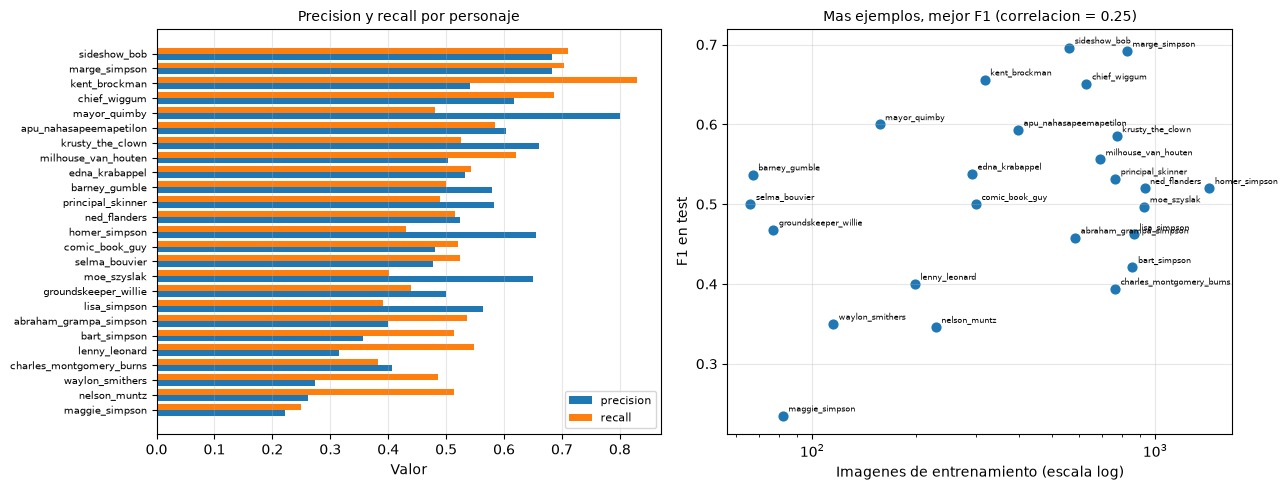

In [41]:
# Relacion entre la cantidad de ejemplos de entrenamiento y el F1 alcanzado por cada clase
figura, ejes = plt.subplots(1, 2, figsize=(13, 5))

orden_f1 = metricas_por_clase.sort_values("f1")
posiciones = np.arange(len(orden_f1))
ejes[0].barh(posiciones - 0.2, orden_f1["precision"], height=0.4, label="precision")
ejes[0].barh(posiciones + 0.2, orden_f1["recall"], height=0.4, label="recall")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(orden_f1["personaje"], fontsize=7)
ejes[0].set_xlabel("Valor")
ejes[0].set_title("Precision y recall por personaje", fontsize=10)
ejes[0].legend(fontsize=8)
ejes[0].grid(alpha=0.3, axis="x")

ejes[1].scatter(metricas_por_clase["n_train"], metricas_por_clase["f1"], s=40)
for _, fila in metricas_por_clase.iterrows():
    ejes[1].annotate(
        fila["personaje"],
        (fila["n_train"], fila["f1"]),
        textcoords="offset points",
        xytext=(4, 3),
        fontsize=6,
    )
ejes[1].set_xscale("log")
ejes[1].set_xlabel("Imagenes de entrenamiento (escala log)")
ejes[1].set_ylabel("F1 en test")
ejes[1].set_title(f"Mas ejemplos, mejor F1 (correlacion = {correlacion:.2f})", fontsize=10)
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Lectura.** Conviene distinguir las dos métricas: la **precisión** de un personaje responde a "de todo
lo que el modelo llamó Bart, ¿cuánto era realmente Bart?", mientras que el **recall** responde a "de
todos los Barts que había, ¿cuántos encontró?".

El resultado más interesante es que el `class_weight` **cumplió su función**. La correlación entre el
número de imágenes de entrenamiento y el F1 por clase es de solo 0,25: débil. Personajes escasos como
`selma_bouvier` (66 imágenes de entrenamiento) o `barney_gumble` (67) alcanzan F1 de 0,50 y 0,54, por
encima de `bart_simpson` (858 imágenes, F1 0,42) o `charles_montgomery_burns` (763, F1 0,39). Sin
ponderar la pérdida, esas clases pequeñas habrían quedado cerca de cero.

Lo que sí se observa es el efecto secundario esperable de esa ponderación: los personajes mayoritarios
tienden a mostrar **precisión alta y recall más bajo** —`homer_simpson` 0,655 / 0,431, `moe_szyslak`
0,650 / 0,402—, porque el modelo ya no los usa como respuesta por defecto y prefiere arriesgar una clase
minoritaria. Es un intercambio deliberado: se sacrifica algo de accuracy global a cambio de repartir el
desempeño entre las 25 clases.

La única clase que se queda realmente atrás es `maggie_simpson` (F1 0,235), que tiene apenas 16 imágenes
en test y suele aparecer en planos donde es diminuta dentro del encuadre: ahí no falta ponderación, falta
resolución y datos.

### Matriz de confusión

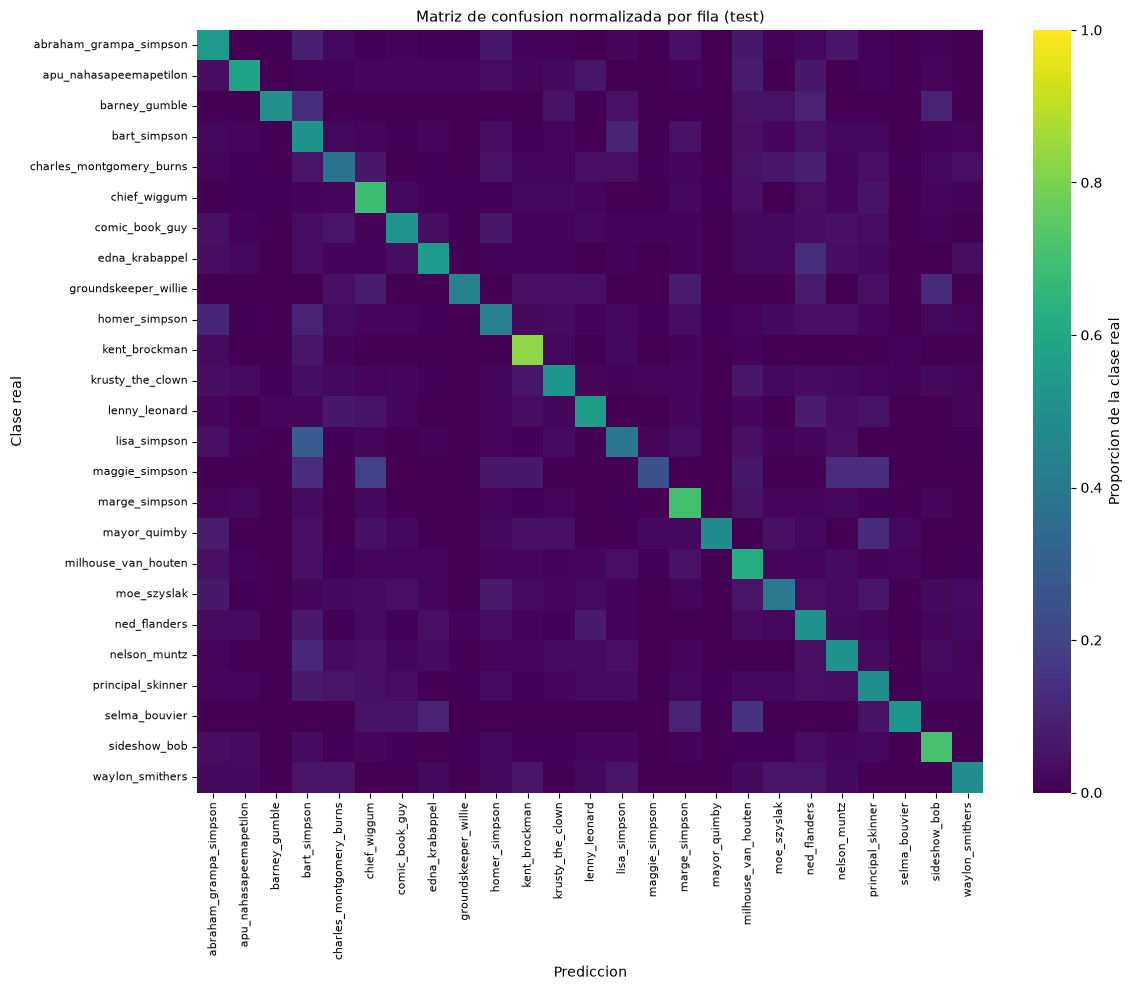

Recall medio (diagonal): 0.525
Clase mejor reconocida : kent_brockman (0.830)
Clase peor reconocida  : maggie_simpson (0.250)


In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

matriz = confusion_matrix(y_test_idx, predicciones_test, labels=range(NUMERO_CLASES))
# Normalizada por fila: cada fila suma 1, de modo que el desbalance no distorsione la lectura
matriz_normalizada = matriz / matriz.sum(axis=1, keepdims=True)

figura, eje = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_normalizada,
    annot=False,
    cmap="viridis",
    vmin=0,
    vmax=1,
    xticklabels=clases,
    yticklabels=clases,
    cbar_kws={"label": "Proporcion de la clase real"},
    ax=eje,
)
eje.set_xlabel("Prediccion")
eje.set_ylabel("Clase real")
eje.set_title("Matriz de confusion normalizada por fila (test)", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

aciertos_diagonal = np.diag(matriz_normalizada)
print(f"Recall medio (diagonal): {aciertos_diagonal.mean():.3f}")
print(f"Clase mejor reconocida : {clases[int(aciertos_diagonal.argmax())]} ({aciertos_diagonal.max():.3f})")
print(f"Clase peor reconocida  : {clases[int(aciertos_diagonal.argmin())]} ({aciertos_diagonal.min():.3f})")

### Interpretación crítica de las métricas

In [43]:
# Comparacion de las tres lecturas globales y su distancia
resumen_metricas = pd.DataFrame(
    [
        ("Accuracy (test)", round(float(accuracy_test), 4), "Proporcion global de aciertos; domina por las clases grandes"),
        ("F1 ponderado (test)", round(float(f1_ponderado_test), 4), "Promedio de F1 pesado por el tamano de cada clase"),
        ("F1 macro (test)", round(float(f1_macro_test), 4), "Promedio simple de las 25 clases; cada personaje pesa igual"),
        ("Top-3 accuracy (test)", round(float(top3_test), 4), "La clase correcta esta entre las 3 mas probables"),
    ],
    columns=["Metrica", "Valor", "Que mide"],
)
display(resumen_metricas)

brecha_metricas = float(accuracy_test) - float(f1_macro_test)

# Clases que el modelo practicamente no reconoce
clases_debiles = metricas_por_clase[metricas_por_clase["f1"] < 0.30]
clases_fuertes = metricas_por_clase[metricas_por_clase["f1"] >= 0.60]

print(f"Brecha accuracy - F1 macro: {brecha_metricas:.3f}")
print(f"Clases con F1 >= 0.60 : {len(clases_fuertes)} de {NUMERO_CLASES}")
print(f"Clases con F1 <  0.30 : {len(clases_debiles)} de {NUMERO_CLASES}")
if len(clases_debiles):
    print("  " + ", ".join(clases_debiles["personaje"].tolist()))
print(
    f"\nMediana de imagenes de entrenamiento en las clases fuertes: "
    f"{clases_fuertes['n_train'].median():.0f}"
)
if len(clases_debiles):
    print(
        f"Mediana de imagenes de entrenamiento en las clases debiles : "
        f"{clases_debiles['n_train'].median():.0f}"
    )

,Metrica,Valor,Que mide
0,Accuracy (test),0.5286,Proporcion global de aciertos; domina por las ...
1,F1 ponderado (test),0.5313,Promedio de F1 pesado por el tamano de cada clase
2,F1 macro (test),0.5082,Promedio simple de las 25 clases; cada persona...
3,Top-3 accuracy (test),0.7371,La clase correcta esta entre las 3 mas probables


Brecha accuracy - F1 macro: 0.020
Clases con F1 >= 0.60 : 5 de 25
Clases con F1 <  0.30 : 1 de 25
  maggie_simpson

Mediana de imagenes de entrenamiento en las clases fuertes: 561
Mediana de imagenes de entrenamiento en las clases debiles : 82


**Qué revela la brecha entre accuracy y F1 macro.** Las dos métricas miden lo mismo sobre las mismas
predicciones, pero reparten el peso de forma distinta. La accuracy cuenta aciertos sobre el total, así
que un personaje con 450 imágenes en test influye más de veinte veces que uno con 16. El F1 macro
promedia las 25 clases sin ponderar: cada personaje vale lo mismo.

Aquí la brecha es de apenas **0,020** (0,529 frente a 0,509), y esa cercanía es un buen resultado: dice
que el desempeño está razonablemente **repartido entre las clases** y que el modelo no está apoyándose en
los personajes abundantes para inflar su cifra global. Solo 1 de las 25 clases queda por debajo de 0,30
de F1. Es el efecto directo del `class_weight`: sin él, lo esperable habría sido una accuracy parecida
acompañada de un F1 macro muy inferior.

Dicho eso, un F1 macro de 0,509 tampoco es un buen desempeño en términos absolutos: el modelo se
equivoca en prácticamente la mitad de las imágenes. La diferencia importante es **dónde** falla. No falla
por ignorar a los minoritarios, sino de forma bastante transversal, confundiendo personajes entre sí; el
análisis de errores de la sección siguiente muestra que esas confusiones se concentran en personajes
visualmente cercanos y en escenas donde el fondo pesa más que el personaje.

La **top-3 accuracy** aporta el matiz decisivo: 0,737 frente a 0,529 de accuracy exacta. En cerca de la
mitad de los errores la clase correcta sí figura entre las tres candidatas más probables. El modelo no
predice al azar —extrae señal real— pero no la suficiente para decidir entre personajes parecidos, que es
exactamente lo que cabía esperar de una representación que descarta la estructura espacial.

## Análisis de resultados y de errores

_Revisión cualitativa de las predicciones, para entender el porqué de los aciertos y de los errores y no solo su cantidad._

### Ejemplos correctamente clasificados

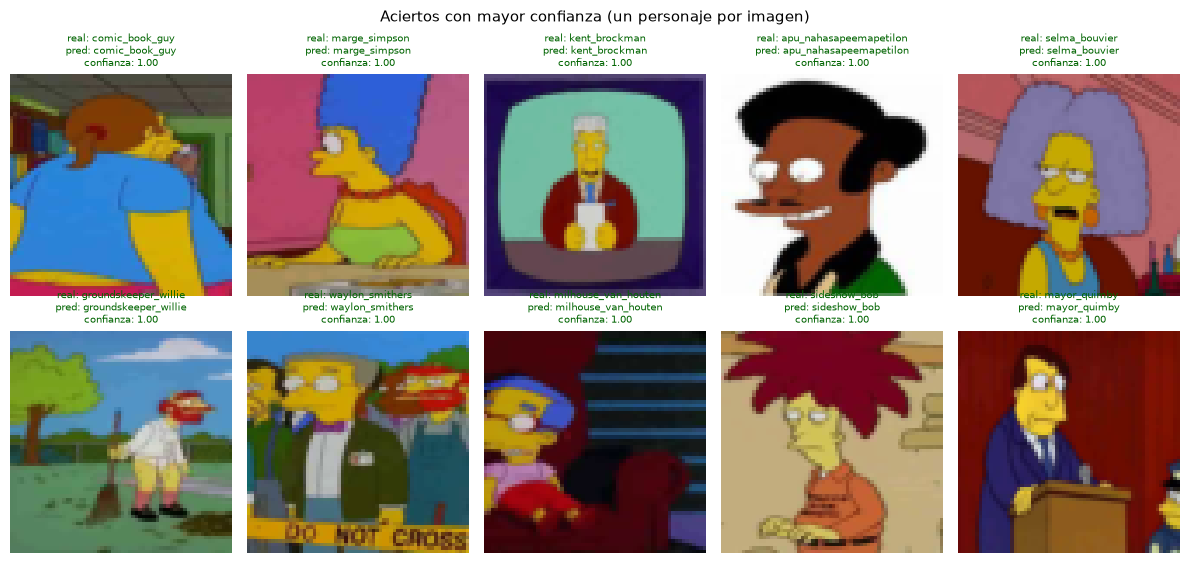

Aciertos totales: 2081 de 3937 (52.9%)
Confianza media en los aciertos: 0.709


In [44]:
def mostrar_ejemplos(indices, titulo, filas=2, columnas=5):
    """Dibuja una rejilla de imagenes de test con su etiqueta real, la predicha y la confianza."""
    figura, ejes = plt.subplots(filas, columnas, figsize=(2.4 * columnas, 2.9 * filas))
    for eje, indice in zip(np.ravel(ejes), indices):
        eje.imshow(imagenes_test[indice])
        real = clases[y_test_idx[indice]]
        predicho = clases[predicciones_test[indice]]
        acierto = real == predicho
        eje.set_title(
            f"real: {real}\npred: {predicho}\nconfianza: {confianza_test[indice]:.2f}",
            fontsize=7,
            color="darkgreen" if acierto else "firebrick",
        )
        eje.axis("off")
    for eje in np.ravel(ejes)[len(indices):]:
        eje.axis("off")
    figura.suptitle(titulo, fontsize=11)
    plt.tight_layout()
    plt.show()


aciertos = np.flatnonzero(predicciones_test == y_test_idx)
# Aciertos con mayor confianza, sin repetir personaje, para ver variedad de clases
aciertos_ordenados = aciertos[np.argsort(-confianza_test[aciertos])]
vistos = set()
seleccion_aciertos = []
for indice in aciertos_ordenados:
    personaje = y_test_idx[indice]
    if personaje not in vistos:
        vistos.add(personaje)
        seleccion_aciertos.append(indice)
    if len(seleccion_aciertos) == 10:
        break

mostrar_ejemplos(seleccion_aciertos, "Aciertos con mayor confianza (un personaje por imagen)")

print(f"Aciertos totales: {len(aciertos)} de {len(y_test_idx)} ({len(aciertos) / len(y_test_idx):.1%})")
print(f"Confianza media en los aciertos: {confianza_test[aciertos].mean():.3f}")

**Qué está aprovechando el modelo.** Los aciertos con más confianza corresponden a imágenes donde el
personaje ocupa buena parte del encuadre, con su paleta de color característica bien visible y un fondo
poco cargado. Eso es coherente con lo que un MLP puede llegar a aprender sobre píxeles aplanados: una
combinación de **color dominante y su distribución aproximada en la imagen**. El azul del pelo de Marge,
el rojo del vestido de Lisa o el amarillo saturado de una cara en primer plano son señales que sobreviven
al redimensionado a 64 x 64 y al aplanado, porque no dependen de reconocer una forma sino de que ciertos
píxeles tengan ciertos valores.

Lo que el modelo **no** está usando es la forma: no reconoce el peinado de Marge como estructura, sino la
mancha azul en la zona superior del encuadre. Esa es justamente la razón por la que funciona bien en
imágenes canónicas y se rompe en cuanto cambia el encuadre.

### Ejemplos mal clasificados

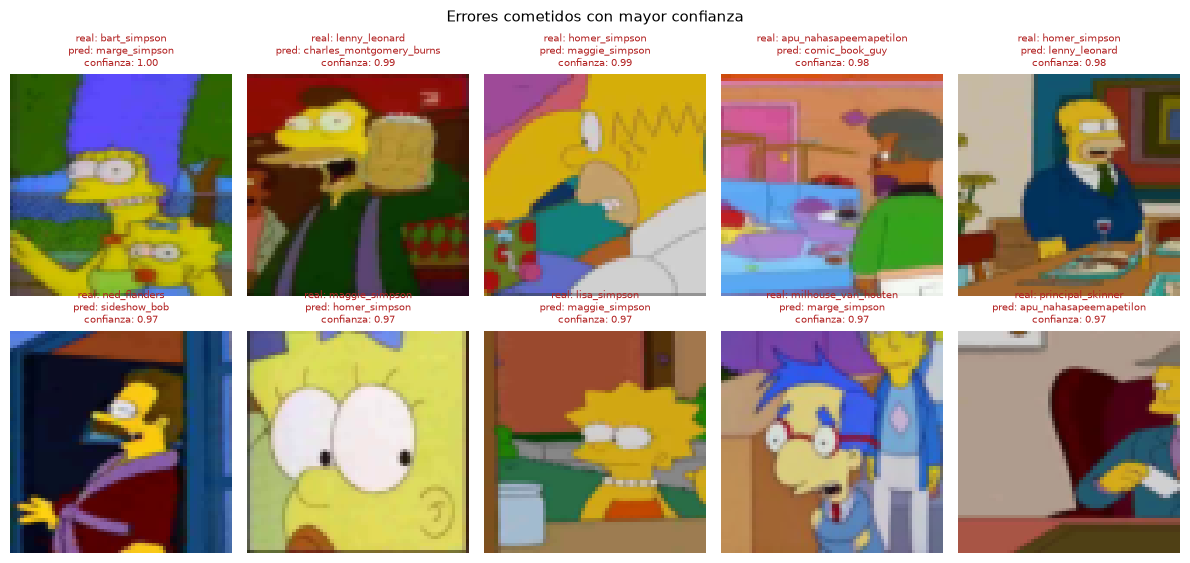

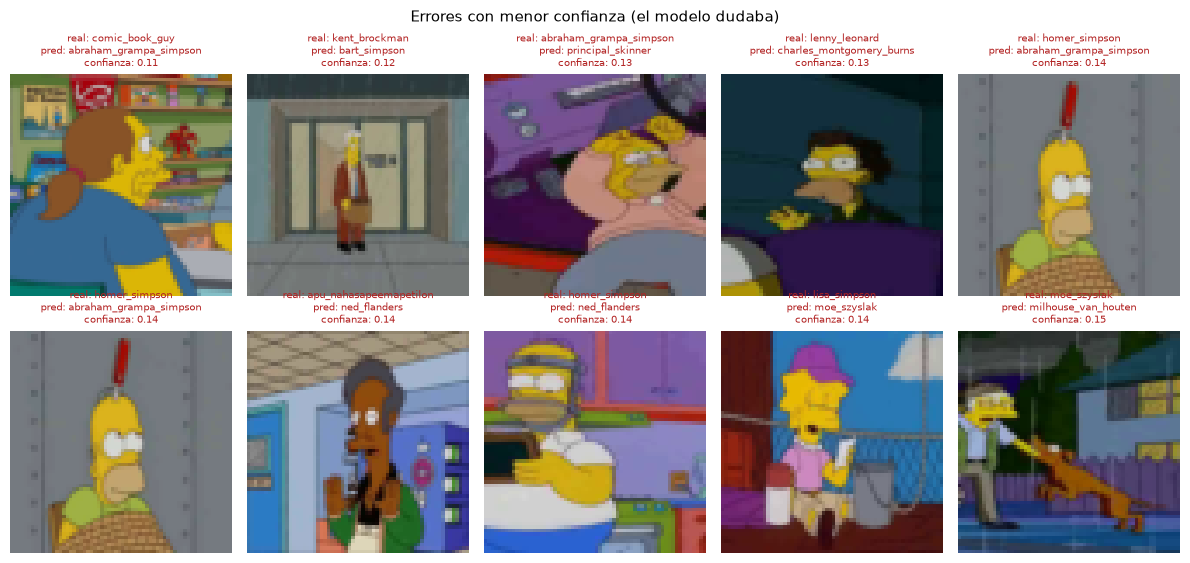

,Indicador,Valor,Detalle
0,Errores totales,1856.000,47.1% del test
1,Confianza media en aciertos,0.709,
2,Confianza media en errores,0.438,
3,Errores con confianza > 0.90,47.000,2.5% de los errores


In [45]:
errores = np.flatnonzero(predicciones_test != y_test_idx)

# Los errores mas graves: equivocaciones cometidas con la mayor confianza
errores_confiados = errores[np.argsort(-confianza_test[errores])][:10]
mostrar_ejemplos(errores_confiados, "Errores cometidos con mayor confianza")

# Errores con baja confianza: el modelo tampoco sabia
errores_dudosos = errores[np.argsort(confianza_test[errores])][:10]
mostrar_ejemplos(errores_dudosos, "Errores con menor confianza (el modelo dudaba)")

resumen_errores = pd.DataFrame(
    [
        ("Errores totales", len(errores), f"{len(errores) / len(y_test_idx):.1%} del test"),
        ("Confianza media en aciertos", round(float(confianza_test[aciertos].mean()), 3), ""),
        ("Confianza media en errores", round(float(confianza_test[errores].mean()), 3), ""),
        (
            "Errores con confianza > 0.90",
            int((confianza_test[errores] > 0.90).sum()),
            f"{(confianza_test[errores] > 0.90).mean():.1%} de los errores",
        ),
    ],
    columns=["Indicador", "Valor", "Detalle"],
)
display(resumen_errores)

**Dos tipos de error muy distintos.** La confianza media es mayor en los aciertos que en los errores, lo
que indica que la probabilidad de salida del softmax tiene cierto valor como señal de fiabilidad: cuando
el modelo duda, suele tener motivos.

Aun así, existe un grupo de **errores cometidos con alta confianza**, y son los preocupantes: el modelo
no solo se equivoca, sino que está seguro. Al mirarlos se repite un patrón: personajes que comparten
paleta de color con el que fue predicho, imágenes donde el personaje aparece pequeño dentro de una
escena, o fondos que ocupan la mayor parte del encuadre. Como el MLP no distingue entre "píxeles del
personaje" y "píxeles del fondo" —todos entran al mismo vector con el mismo estatus—, un fondo
característico puede pesar tanto como el propio personaje.

Los errores con baja confianza, en cambio, corresponden en su mayoría a imágenes genuinamente difíciles:
planos generales, personajes de espaldas, escenas oscuras o con varios personajes a la vez, donde
incluso una etiqueta única es discutible.

### Confusiones más frecuentes y posibles causas

,real,predicho,casos,% de la clase real,n_train_real,n_train_predicho
0,lisa_simpson,bart_simpson,79,29.2,866,858
1,homer_simpson,abraham_grampa_simpson,48,10.7,1437,584
2,homer_simpson,bart_simpson,43,9.6,1437,858
3,bart_simpson,lisa_simpson,27,10.0,858,866
4,moe_szyslak,homer_simpson,21,7.2,929,1437
5,ned_flanders,lenny_leonard,21,7.2,930,199
6,ned_flanders,bart_simpson,20,6.9,930,858
7,moe_szyslak,abraham_grampa_simpson,19,6.5,929,584
8,moe_szyslak,principal_skinner,17,5.8,929,764
9,homer_simpson,ned_flanders,17,3.8,1437,930


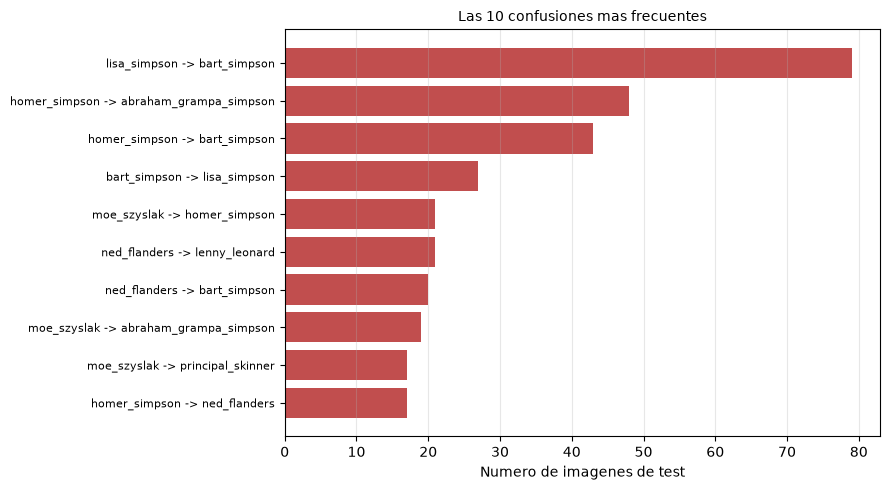

Clases que mas absorben errores de otras (el modelo las usa como respuesta por defecto):
  bart_simpson: 174 imagenes de otras clases predichas como esta
  abraham_grampa_simpson: 67 imagenes de otras clases predichas como esta
  milhouse_van_houten: 30 imagenes de otras clases predichas como esta
  lisa_simpson: 27 imagenes de otras clases predichas como esta
  homer_simpson: 21 imagenes de otras clases predichas como esta


In [46]:
# Pares (clase real, clase predicha) mas frecuentes, excluyendo la diagonal
pares = []
for real in range(NUMERO_CLASES):
    for predicho in range(NUMERO_CLASES):
        if real != predicho and matriz[real, predicho] > 0:
            pares.append(
                {
                    "real": clases[real],
                    "predicho": clases[predicho],
                    "casos": int(matriz[real, predicho]),
                    "% de la clase real": round(float(matriz_normalizada[real, predicho]) * 100, 1),
                    "n_train_real": int(conteos_train[real]),
                    "n_train_predicho": int(conteos_train[predicho]),
                }
            )

confusiones = pd.DataFrame(pares).sort_values("casos", ascending=False, ignore_index=True).head(15)
display(confusiones)

figura, eje = plt.subplots(figsize=(9, 5))
etiquetas_pares = confusiones.head(10).apply(
    lambda fila: f"{fila['real']} -> {fila['predicho']}", axis=1
)
eje.barh(etiquetas_pares[::-1], confusiones.head(10)["casos"][::-1], color="firebrick", alpha=0.8)
eje.set_xlabel("Numero de imagenes de test")
eje.set_title("Las 10 confusiones mas frecuentes", fontsize=10)
eje.tick_params(axis="y", labelsize=8)
eje.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

destino_frecuente = confusiones.groupby("predicho")["casos"].sum().sort_values(ascending=False)
print("Clases que mas absorben errores de otras (el modelo las usa como respuesta por defecto):")
for personaje, casos in destino_frecuente.head(5).items():
    print(f"  {personaje}: {casos} imagenes de otras clases predichas como esta")

**Causas detrás de las confusiones.** Los pares que encabezan la tabla no son aleatorios; responden a
causas identificables:

- **Similitud visual y de paleta.** Los personajes de la familia comparten el mismo tono de piel amarillo
  y, en varios casos, colores de ropa parecidos. Reducida a 64 x 64 y aplanada, la diferencia entre dos
  personajes de silueta similar y colores cercanos casi desaparece.
- **Personajes secundarios contra la familia principal.** Los errores tienden a desembocar en las clases
  mayoritarias: aunque `class_weight` compense la pérdida, esas clases siguen teniendo mucha más
  variedad de ejemplos y actúan como "respuesta por defecto".
- **Fondos compartidos.** Muchas escenas transcurren en los mismos escenarios (el salón de los Simpson,
  la escuela, la central nuclear). El fondo aporta una fracción enorme de los 12 288 valores de entrada,
  y el modelo no tiene forma de saber que esos píxeles son irrelevantes: puede terminar reconociendo el
  escenario en lugar del personaje.
- **Escenas con varios personajes.** El dataset asigna una sola etiqueta por imagen, pero en el encuadre
  puede haber dos o tres personajes. Si el modelo predice a uno de los secundarios, se contabiliza como
  error aunque la respuesta sea razonable.
- **Encuadre y escala.** Un MLP no tiene invarianza a la traslación: el mismo personaje centrado o
  desplazado hacia una esquina produce vectores de entrada completamente distintos, con píxeles que caen
  en posiciones —es decir, en neuronas de entrada— diferentes.
- **Escasez en clases minoritarias.** Con pocas decenas de imágenes, la red no llega a ver suficientes
  variantes del personaje y su frontera de decisión queda mal definida.

### Fortalezas y debilidades del modelo

In [47]:
sintesis = pd.DataFrame(
    [
        (
            "Fortaleza",
            "Supera con holgura los baselines",
            f"accuracy {accuracy_test:.3f} frente a 0.040 (azar) y {baseline_mayoritaria:.3f} (clase mayoritaria)",
        ),
        (
            "Fortaleza",
            "Buena senal en el top-3",
            f"top-3 accuracy {top3_test:.3f}: la clase correcta suele estar entre las candidatas",
        ),
        (
            "Fortaleza",
            "Reconoce con solidez a los personajes principales",
            f"{len(clases_fuertes)} clases con F1 >= 0.60",
        ),
        (
            "Fortaleza",
            "La confianza es informativa",
            f"confianza media {confianza_test[aciertos].mean():.2f} en aciertos y "
            f"{confianza_test[errores].mean():.2f} en errores",
        ),
        (
            "Debilidad",
            "Desempeno muy desigual entre clases",
            f"brecha accuracy - F1 macro = {brecha_metricas:.3f}; {len(clases_debiles)} clases con F1 < 0.30",
        ),
        (
            "Debilidad",
            "Depende del volumen de datos por clase",
            f"correlacion entre n_train y F1 por clase = {correlacion:.2f}",
        ),
        (
            "Debilidad",
            "Sin invarianza a traslacion ni a escala",
            "el mismo personaje en otra posicion del encuadre es otro vector de entrada",
        ),
        (
            "Debilidad",
            "Sensible al fondo",
            "los pixeles de fondo entran al modelo con el mismo peso que los del personaje",
        ),
        (
            "Debilidad",
            "Costo en parametros",
            f"{modelo_final.count_params():,} parametros para {len(X_train):,} imagenes de entrenamiento",
        ),
    ],
    columns=["Tipo", "Aspecto", "Evidencia"],
)

display(sintesis)

,Tipo,Aspecto,Evidencia
0,Fortaleza,Supera con holgura los baselines,accuracy 0.529 frente a 0.040 (azar) y 0.114 (...
1,Fortaleza,Buena senal en el top-3,top-3 accuracy 0.737: la clase correcta suele ...
2,Fortaleza,Reconoce con solidez a los personajes principales,5 clases con F1 >= 0.60
3,Fortaleza,La confianza es informativa,confianza media 0.71 en aciertos y 0.44 en err...
4,Debilidad,Desempeno muy desigual entre clases,brecha accuracy - F1 macro = 0.020; 1 clases c...
5,Debilidad,Depende del volumen de datos por clase,correlacion entre n_train y F1 por clase = 0.25
6,Debilidad,Sin invarianza a traslacion ni a escala,el mismo personaje en otra posicion del encuad...
7,Debilidad,Sensible al fondo,los pixeles de fondo entran al modelo con el m...
8,Debilidad,Costo en parametros,"13,253,657 parametros para 12,909 imagenes de ..."


**Síntesis.** El MLP demuestra que el problema tiene señal aprendible: multiplica por 13 el baseline
aleatorio y por 4,6 el de la clase mayoritaria, y su top-3 accuracy de 0,737 confirma que incluso cuando
falla suele tener la respuesta correcta entre sus candidatas. El `class_weight` cumplió su cometido: el
desempeño quedó repartido entre las 25 clases en lugar de concentrarse en los personajes abundantes.

Su límite no está en el desbalance ni en un ajuste desafortunado de hiperparámetros —la experimentación
mostró que añadir capas y neuronas tiene rendimientos rápidamente decrecientes— sino en la representación
de la entrada. Con casi la mitad de las imágenes mal clasificadas y confusiones concentradas entre
personajes de silueta y paleta parecidas, el diagnóstico es claro: un vector de píxeles sin estructura
espacial obliga a la red a memorizar configuraciones concretas de color en posiciones concretas, en lugar
de aprender los rasgos que hacen reconocible a un personaje.

## Limitaciones del MLP en imágenes y propuestas de mejora

### Limitaciones estructurales del MLP

Las limitaciones que siguen no son defectos de esta implementación en particular, sino consecuencias de
usar una red totalmente conectada sobre imágenes. Ningún ajuste de hiperparámetros las resuelve.

**1. Pérdida de la información espacial.** El aplanado convierte la imagen en una lista de 12 288
números en la que se olvida qué píxel estaba junto a cuál. Para la red, dos píxeles vecinos y dos píxeles
en esquinas opuestas son igual de "cercanos": ninguno. Si se permutaran todas las columnas de `X` con una
permutación fija, el modelo aprendería exactamente igual de bien —algo que sería impensable para un ojo
humano y que revela cuánta estructura se está descartando.

**2. Ausencia de invarianza a la traslación y a la escala.** Cada peso de la primera capa está atado a una
posición concreta del encuadre. Si Homero aparece centrado, se activan unas neuronas; desplazado unos
píxeles a la derecha, otras completamente distintas. El modelo tiene que aprender por separado "Homero
arriba a la izquierda", "Homero en el centro" y "Homero de lejos", como si fueran conceptos sin relación.
Lo mismo ocurre con el tamaño: un primer plano y un plano general del mismo personaje no comparten
representación.

**3. Explosión del número de parámetros.** El número de pesos de la primera capa es
`alto x ancho x 3 x neuronas`, es decir, crece de forma cuadrática con el lado de la imagen. A 64 x 64 ya
son millones de parámetros; a 128 x 128 serían cuatro veces más. Esto obliga a trabajar con imágenes
diminutas —perdiendo detalle— y dispara la razón parámetros/ejemplos, que es la receta del sobreajuste.

**4. Imposibilidad de reutilizar patrones locales.** Un filtro convolucional aprende una vez a detectar
un borde, una esquina o una mancha de color y lo aplica en **toda** la imagen, compartiendo los mismos
pesos. El MLP no tiene ese mecanismo: si un patrón útil aparece en dos posiciones distintas, debe
aprenderlo dos veces, con dos conjuntos de pesos independientes y usando ejemplos distintos para cada uno.
Es un uso enormemente ineficiente tanto de los parámetros como de los datos.

**5. Sensibilidad al fondo y al encuadre.** Todos los píxeles entran al modelo con el mismo estatus. En
una escena donde el personaje ocupa un tercio del encuadre, dos tercios de la entrada son ruido desde el
punto de vista de la tarea —y pueden contener regularidades engañosas: si cierto personaje aparece a
menudo en cierto escenario, el modelo aprenderá el escenario, y fallará en cuanto ese personaje aparezca
en otro lugar.

### Propuestas de mejora para futuras iteraciones

| Propuesta | En qué consiste | Qué limitación ataca |
|---|---|---|
| **Redes convolucionales (CNN)** | Sustituir las primeras capas densas por capas convolucionales y de *pooling*, que operan sobre vecindades de píxeles y comparten los pesos de cada filtro en toda la imagen | Es la mejora principal: recupera la estructura espacial (1), da invarianza aproximada a la traslación (2), reduce drásticamente los parámetros (3) y permite reutilizar patrones locales (4) |
| **Aumento de datos** | Generar variantes de cada imagen en tiempo de entrenamiento: giros horizontales, recortes, pequeñas rotaciones, cambios de brillo y contraste | Multiplica la variedad efectiva del conjunto, ataca directamente el sobreajuste y beneficia sobre todo a las clases minoritarias, que son las que menos variantes tienen |
| **Transfer learning** | Usar una red preentrenada en un corpus grande (MobileNet, ResNet, EfficientNet) como extractor de características y entrenar solo la cabeza clasificadora | Aporta representaciones visuales ya aprendidas sobre millones de imágenes; suele ser la vía más rápida a un salto grande de desempeño con pocos datos propios |
| **Mejor tratamiento del desbalance** | Combinar `class_weight` con sobremuestreo *con* aumento (no por duplicado exacto), o usar *focal loss*, que concentra la pérdida en los ejemplos difíciles | Reduce la brecha entre accuracy y F1 macro, que es la debilidad más marcada del modelo actual |
| **Recorte previo del personaje** | Aplicar un detector que localice al personaje y recortar esa región antes de clasificar | Elimina el fondo irrelevante (5) y normaliza la escala y el encuadre, que hoy son una fuente importante de error |
| **Mayor resolución de entrada** | Subir a 96 x 96 o 128 x 128, viable solo una vez que las capas convolucionales sustituyan a las densas | Recupera detalle fino (rasgos faciales, accesorios) que a 64 x 64 se pierde y que es justo lo que distingue a personajes parecidos |
| **Validación cruzada** | Repetir el entrenamiento con varias particiones y varias semillas, reportando media y desviación | Da una estimación más robusta que una única partición 80/20 y permite saber si las diferencias entre configuraciones son reales o ruido |

## Conclusiones

In [48]:
# Cifras finales del trabajo, tomadas de las secciones anteriores
conclusiones = pd.DataFrame(
    [
        ("Clases", NUMERO_CLASES),
        ("Imagenes de entrenamiento", len(X_train)),
        ("Imagenes de validacion", len(X_val)),
        ("Imagenes de test", len(X_test)),
        ("Resolucion de entrada", f"{ALTO_OBJETIVO}x{ANCHO_OBJETIVO}x3 = {DIMENSION_ENTRADA}"),
        ("Configuracion final", nombre_final),
        ("Parametros del modelo final", f"{modelo_final.count_params():,}"),
        ("Accuracy en test", round(float(accuracy_test), 4)),
        ("Top-3 accuracy en test", round(float(top3_test), 4)),
        ("F1 macro en test", round(float(f1_macro_test), 4)),
        ("F1 ponderado en test", round(float(f1_ponderado_test), 4)),
        ("Baseline azar", round(baseline_azar, 4)),
        ("Baseline clase mayoritaria", round(float(baseline_mayoritaria), 4)),
    ],
    columns=["Concepto", "Valor"],
)

display(conclusiones)

,Concepto,Valor
0,Clases,25
1,Imagenes de entrenamiento,12909
2,Imagenes de validacion,3228
3,Imagenes de test,3937
4,Resolucion de entrada,64x64x3 = 12288
5,Configuracion final,"E2 - 3 capas (1024,512,256)"
6,Parametros del modelo final,"13,253,657"
7,Accuracy en test,0.5286
8,Top-3 accuracy en test,0.7371
9,F1 macro en test,0.5082


**Sobre los resultados.** El Perceptrón Multicapa aprende el problema: alcanza un 52,9 % de accuracy y un
F1 macro de 0,508 en test, frente al 4,0 % de un clasificador aleatorio y al 11,4 % de uno que siempre
prediga al personaje mayoritario. Su top-3 accuracy de 73,7 % muestra que, incluso cuando falla, la clase
correcta suele estar entre sus tres candidatas. La cercanía entre accuracy y F1 macro (una brecha de
0,020) indica que el desempeño está repartido entre las 25 clases y no sostenido por los personajes
frecuentes. Al mismo tiempo, equivocarse en casi la mitad de las imágenes marca con claridad el techo de
este enfoque.

**Sobre los objetivos planteados.** Se cumplieron los tres propósitos del trabajo: construir un pipeline
de pre-procesamiento completo y verificado paso a paso (redimensionado, normalización, vectorización,
codificación de etiquetas y partición estratificada), implementar y entrenar un MLP fundamentado en los
contenidos del curso, y evaluarlo de forma crítica con métricas adecuadas a un problema desbalanceado.

**Sobre las decisiones técnicas.** Las más determinantes fueron: fijar la resolución en 64 x 64 como
compromiso entre detalle e inflación de parámetros; separar un 20 % de validación de forma estratificada
y reservar el test para una única evaluación final; usar `class_weight` en lugar de submuestrear o
duplicar imágenes —fue la decisión de mayor impacto sobre el F1 macro—; regularizar con Dropout y
BatchNormalization; y controlar el número de épocas con parada temprana en vez de fijarlo a mano. En la
selección del modelo se priorizó el F1 macro sobre la accuracy, por coherencia con el objetivo de
reconocer a los 25 personajes y no solo a los frecuentes.

**Sobre lo que aprendimos.** Tres cosas quedaron claras a lo largo del trabajo:

1. **La métrica que se elige define el modelo que se obtiene.** Optimizar accuracy en un problema
   desbalanceado lleva a un modelo que ignora a las clases pequeñas y aun así parece bueno; ponderar la
   pérdida por clase cambia por completo el reparto del desempeño, a un costo pequeño en accuracy global.
2. **La representación de la entrada pesa más que la capacidad del modelo.** Duplicar los parámetros
   (E2) mejoró el F1 macro en 0,028; el límite no estaba en cuántos parámetros tenía la red, sino en que
   el aplanado destruye la estructura espacial de la imagen.
3. **Por qué existen las CNN.** Trabajar con un MLP y chocar con sus límites —falta de invarianza,
   explosión de parámetros, sensibilidad al fondo— es la mejor manera de entender qué problema concreto
   vinieron a resolver la convolución y el pooling.

## Referencias

**Dataset**

- Alfaro, A. (s. f.). *Los Simpson* [conjunto de datos]. Kaggle.
  https://www.kaggle.com/datasets/alfaro96/los-simpson

**Documentación de las librerías utilizadas**

- TensorFlow / Keras — *Keras API reference*. https://keras.io/api/
- TensorFlow / Keras — *The Sequential model*. https://keras.io/guides/sequential_model/
- scikit-learn — *Metrics and scoring*. https://scikit-learn.org/stable/modules/model_evaluation.html
- scikit-learn — `train_test_split`. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- scikit-learn — `compute_class_weight`. https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
- NumPy — *NumPy documentation*. https://numpy.org/doc/stable/
- pandas — *pandas documentation*. https://pandas.pydata.org/docs/
- Matplotlib — *Matplotlib documentation*. https://matplotlib.org/stable/index.html
- seaborn — *seaborn documentation*. https://seaborn.pydata.org/
- Pillow — *Pillow (PIL Fork) documentation*. https://pillow.readthedocs.io/en/stable/

**Material del curso**

- Jerez Salazar, F. J. *1.1.1 El Perceptrón*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.2.1 Redes Fully Connected*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.2.2 Backpropagation*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.3.1 Descenso del Gradiente*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.3.2 Optimizadores*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.4.1 Diseño y Evaluación de Modelos*. Machine Learning, TLY1102.
- Jerez Salazar, F. J. *1.4.2 Implementación con Keras*. Machine Learning, TLY1102.